In [64]:
# pip install pandas matplotlib seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

# Load Dataset

In [2]:
df=pd.read_csv('../data/train.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,...,314.0,NaN,0,Transient,38.40,0,0,Check-Out,2019-01-14,1
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,...,1.0,NaN,0,Transient,62.80,0,0,Canceled,2017-10-21,2
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,...,12.0,NaN,0,Transient,110.00,0,0,Canceled,2018-11-25,3
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,...,NaN,200.0,0,Transient,45.00,0,0,Check-Out,2018-10-18,4
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,...,16.0,NaN,0,Transient,57.92,0,1,Canceled,2017-08-24,5


In [3]:
# Spilt data -> train, test
X=df.copy()

In [4]:
X

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,...,314.0,NaN,0,Transient,38.40,0,0,Check-Out,2019-01-14,1
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,...,1.0,NaN,0,Transient,62.80,0,0,Canceled,2017-10-21,2
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,...,12.0,NaN,0,Transient,110.00,0,0,Canceled,2018-11-25,3
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,...,NaN,200.0,0,Transient,45.00,0,0,Check-Out,2018-10-18,4
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,...,16.0,NaN,0,Transient,57.92,0,1,Canceled,2017-08-24,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83288,"Crystal Cove, Barbados Barbados",0,4,2018,October,44,25,0,2,2,...,9.0,NaN,0,Transient,169.00,1,1,Check-Out,2018-10-27,83289
83289,"Berlin Marriott Hotel Berlin, Germany",0,30,2017,September,38,14,1,3,2,...,9.0,NaN,0,Transient,94.50,0,2,Check-Out,2017-09-18,83290
83290,"The Ritz-Carlton, Tokyo Tokyo, Japan",0,165,2019,June,25,21,4,10,2,...,NaN,NaN,0,Transient,123.50,0,1,Check-Out,2019-07-05,83291
83291,"Colony Club, Barbados Barbados",0,180,2018,July,32,31,2,4,2,...,9.0,NaN,0,Transient,122.25,0,1,Check-Out,2018-08-06,83292


In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83290 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            

# Exploratory Data Analysis
Tujuan Pengolahan data ini adalah mengurangi pembatalan reservasi, sehingga perlu memahami mengapa pelanggan membatalkan pemesanan dari faktor-faktor yang mempengaruhi pembatalan

Presentase Cancellation:
is_canceled
0    63.049716
1    36.950284
Name: proportion, dtype: float64


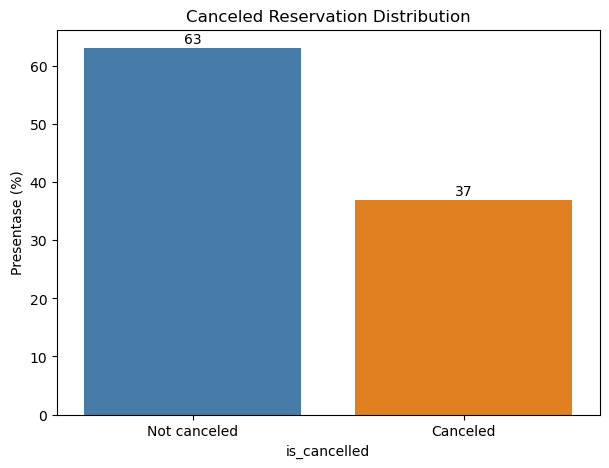

In [6]:
# Presentase cancellation
cancel_rate=df['is_canceled'].value_counts(normalize=True)*100
print(f'Presentase Cancellation:\n{cancel_rate}')

#Tingkat pembatalan 
plt.figure(figsize=(7, 5))
custom_palette=['#377eb8', '#ff7f00']
ax= sns.barplot(x=cancel_rate.index, y=cancel_rate.values, hue=cancel_rate.index, palette=custom_palette, legend=False)

# Label diatas bar chart
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width()/ 2.0,
        p.get_height() + 0.3,
        '{0:.0f}'.format(p.get_height()),
        ha='center',
        va='bottom'
    )

# Visualisasi
plt.title('Canceled Reservation Distribution')
plt.xlabel('is_cancelled')
plt.ylabel('Presentase (%)')
plt.xticks([0,1],['Not canceled','Canceled'])
plt.show()

Analysis:
- Hasil menunjukkan sebanyak 63 persen yang tidak membatalkan reservasi
- Data tidak balance tapi masih aman, tidak perlu ditanganani dengan smote

In [7]:
#info data numericals
numericals=df.select_dtypes(include=['number']).columns
df[numericals].describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,bookingID
count,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000,83290.000000,83293.000000,...,83293.000000,83293.000000,83293.000000,71889.000000,4734.000000,83293.000000,83293.000000,83293.000000,83293.000000,83293.000000
mean,0.369503,103.914230,2018.156808,27.164023,15.786116,0.930390,2.503812,1.854466,0.103614,0.008032,...,0.086994,0.141765,0.223068,86.867282,190.003802,2.352238,101.724373,0.061818,0.571945,41647.000000
std,0.482673,106.874124,0.706656,13.623752,8.775931,1.004196,1.924511,0.606139,0.398821,0.100641,...,0.862988,1.554390,0.656237,110.875605,131.969152,17.820652,48.082552,0.245027,0.793742,24044.762323
min,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,18.000000,2018.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.530000,0.000000,0.000000,20824.000000
50%,0.000000,69.000000,2018.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,14.000000,183.000000,0.000000,94.500000,0.000000,0.000000,41647.000000
75%,1.000000,160.000000,2019.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000,62470.000000
max,1.000000,737.000000,2019.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,26.000000,70.000000,21.000000,535.000000,543.000000,391.000000,508.000000,8.000000,5.000000,83293.000000


Obsevasi:
- rata-rata not canceled
- range pemesnan 2017-2019
- rata rata customer nginep 2 malam di weekend
- rata-rata customer nginep 3 malam di hari kerja
- rata-rata customer dua orang dewasa
- rata-rata cutomer tambahan seperti childeren and babies 0

In [8]:
#info data categorical
categorical=df.select_dtypes(include=['object']).columns
df[categorical].describe()

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,83293,83293,83293,82947,83293,83293,83293,83293,83293,83293,83293,83293
unique,64,12,5,165,8,5,10,11,3,4,3,914
top,Renaissance New York Times Square Hotel New Yo...,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2017-10-21
freq,1373,9643,64424,33952,39445,68368,60062,51702,72979,62535,52516,1024


Observasi:
- Hotel yang paling banyak dipesan adalah Renaissance New York Times Square Hotel New York
- Bulan Agustus banyak customer tiba
- Untuk paket meal customer paling banyak memilih BB
- Customer paling banyak dari kota Portugal

In [9]:
X['country'].unique()

array(['ITA', 'PRT', nan, 'BEL', 'DNK', 'GBR', 'IRL', 'ESP', 'DEU', 'RUS',
       'NOR', 'CN', 'USA', 'AUS', 'CHE', 'NLD', 'FRA', 'CHN', 'TUR',
       'BRA', 'KOR', 'PLW', 'ZAF', 'POL', 'HUN', 'MOZ', 'HKG', 'IND',
       'LUX', 'MAR', 'FIN', 'ISR', 'DZA', 'SWE', 'CYP', 'GRC', 'OMN',
       'AUT', 'JPN', 'SVN', 'AGO', 'MCO', 'ARG', 'MYS', 'LVA', 'LTU',
       'MEX', 'STP', 'SAU', 'MRT', 'NGA', 'SVK', 'COL', 'THA', 'ROU',
       'SUR', 'BGR', 'EST', 'ARE', 'VEN', 'SGP', 'BIH', 'CHL', 'HRV',
       'URY', 'TWN', 'ALB', 'GNB', 'BLR', 'SRB', 'GEO', 'CUB', 'CZE',
       'ZMB', 'ZWE', 'BHR', 'KEN', 'IRN', 'PER', 'ISL', 'TJK', 'LBN',
       'NZL', 'MAC', 'SEN', 'PHL', 'JOR', 'AND', 'DJI', 'KAZ', 'GTM',
       'IRQ', 'GAB', 'LBY', 'MDV', 'TUN', 'EGY', 'UKR', 'GIB', 'PRY',
       'KWT', 'KNA', 'IDN', 'CPV', 'GLP', 'COM', 'AZE', 'UGA', 'MKD',
       'LAO', 'SYC', 'MLT', 'PAK', 'QAT', 'AIA', 'FJI', 'DOM', 'ECU',
       'PRI', 'CRI', 'CAF', 'MMR', 'ARM', 'SLV', 'TZA', 'HND', 'BEN',
       'KHM', 'F

In [10]:
X['hotel'].unique()

array(['Crystal Cove, Barbados Barbados',
       'Greensboro Courtyard Greensboro, NC',
       'The Westin Peachtree Plaza, Atlanta Atlanta, GA ',
       'Courtyard by Marriott Aberdeen Airport Aberdeen, United Kingdom',
       'W New York – Union Square New York, NY',
       'Hotel Maria Cristina, San Sebastian San Sebastian, Spain',
       'W New York – Times Square New York, NY',
       'The Ritz-Carlton, Tokyo Tokyo, Japan',
       'Marriott Puerto Vallarta Resort & Spa Puerto Vallarta, Mexico',
       'Las Vegas Marriott Las Vegas, NV ',
       'Heidelberg Marriott Hotel Heidelberg, Germany',
       'Sheraton Grand Rio Hotel & Resort Rio de Janeiro, Brazil',
       'Renaissance Hamburg Hotel Hamburg, Germany',
       'The Ritz-Carlton, Berlin Berlin, Germany',
       'Sheraton Lima Hotel & Convention Center Lima, Peru',
       'Courtyard Las Vegas Convention Center Las Vegas, NV ',
       'Newark Liberty International Airport Courtyard Newark, NJ',
       'Indianapolis Airport Cou

In [11]:
# List unik dari negara asal pelanggan
print("Negara asal pelanggan unik dalam dataset:")
print(df['country'].dropna().unique())

# List unik dari hotel
print("\nLokasi hotel unik dalam dataset:")
print(df['hotel'].unique())


Negara asal pelanggan unik dalam dataset:
['ITA' 'PRT' 'BEL' 'DNK' 'GBR' 'IRL' 'ESP' 'DEU' 'RUS' 'NOR' 'CN' 'USA'
 'AUS' 'CHE' 'NLD' 'FRA' 'CHN' 'TUR' 'BRA' 'KOR' 'PLW' 'ZAF' 'POL' 'HUN'
 'MOZ' 'HKG' 'IND' 'LUX' 'MAR' 'FIN' 'ISR' 'DZA' 'SWE' 'CYP' 'GRC' 'OMN'
 'AUT' 'JPN' 'SVN' 'AGO' 'MCO' 'ARG' 'MYS' 'LVA' 'LTU' 'MEX' 'STP' 'SAU'
 'MRT' 'NGA' 'SVK' 'COL' 'THA' 'ROU' 'SUR' 'BGR' 'EST' 'ARE' 'VEN' 'SGP'
 'BIH' 'CHL' 'HRV' 'URY' 'TWN' 'ALB' 'GNB' 'BLR' 'SRB' 'GEO' 'CUB' 'CZE'
 'ZMB' 'ZWE' 'BHR' 'KEN' 'IRN' 'PER' 'ISL' 'TJK' 'LBN' 'NZL' 'MAC' 'SEN'
 'PHL' 'JOR' 'AND' 'DJI' 'KAZ' 'GTM' 'IRQ' 'GAB' 'LBY' 'MDV' 'TUN' 'EGY'
 'UKR' 'GIB' 'PRY' 'KWT' 'KNA' 'IDN' 'CPV' 'GLP' 'COM' 'AZE' 'UGA' 'MKD'
 'LAO' 'SYC' 'MLT' 'PAK' 'QAT' 'AIA' 'FJI' 'DOM' 'ECU' 'PRI' 'CRI' 'CAF'
 'MMR' 'ARM' 'SLV' 'TZA' 'HND' 'BEN' 'KHM' 'FRO' 'BFA' 'RWA' 'BOL' 'VNM'
 'BRB' 'TMP' 'BGD' 'MUS' 'NPL' 'ABW' 'ETH' 'CMR' 'PAN' 'CIV' 'MYT' 'JAM'
 'SYR' 'UZB' 'UMI' 'LKA' 'JEY' 'ASM' 'CYM' 'NIC' 'KIR' 'GHA' 'SDN' 'MNE'
 'DMA' 'MW

## Univariate Analysis

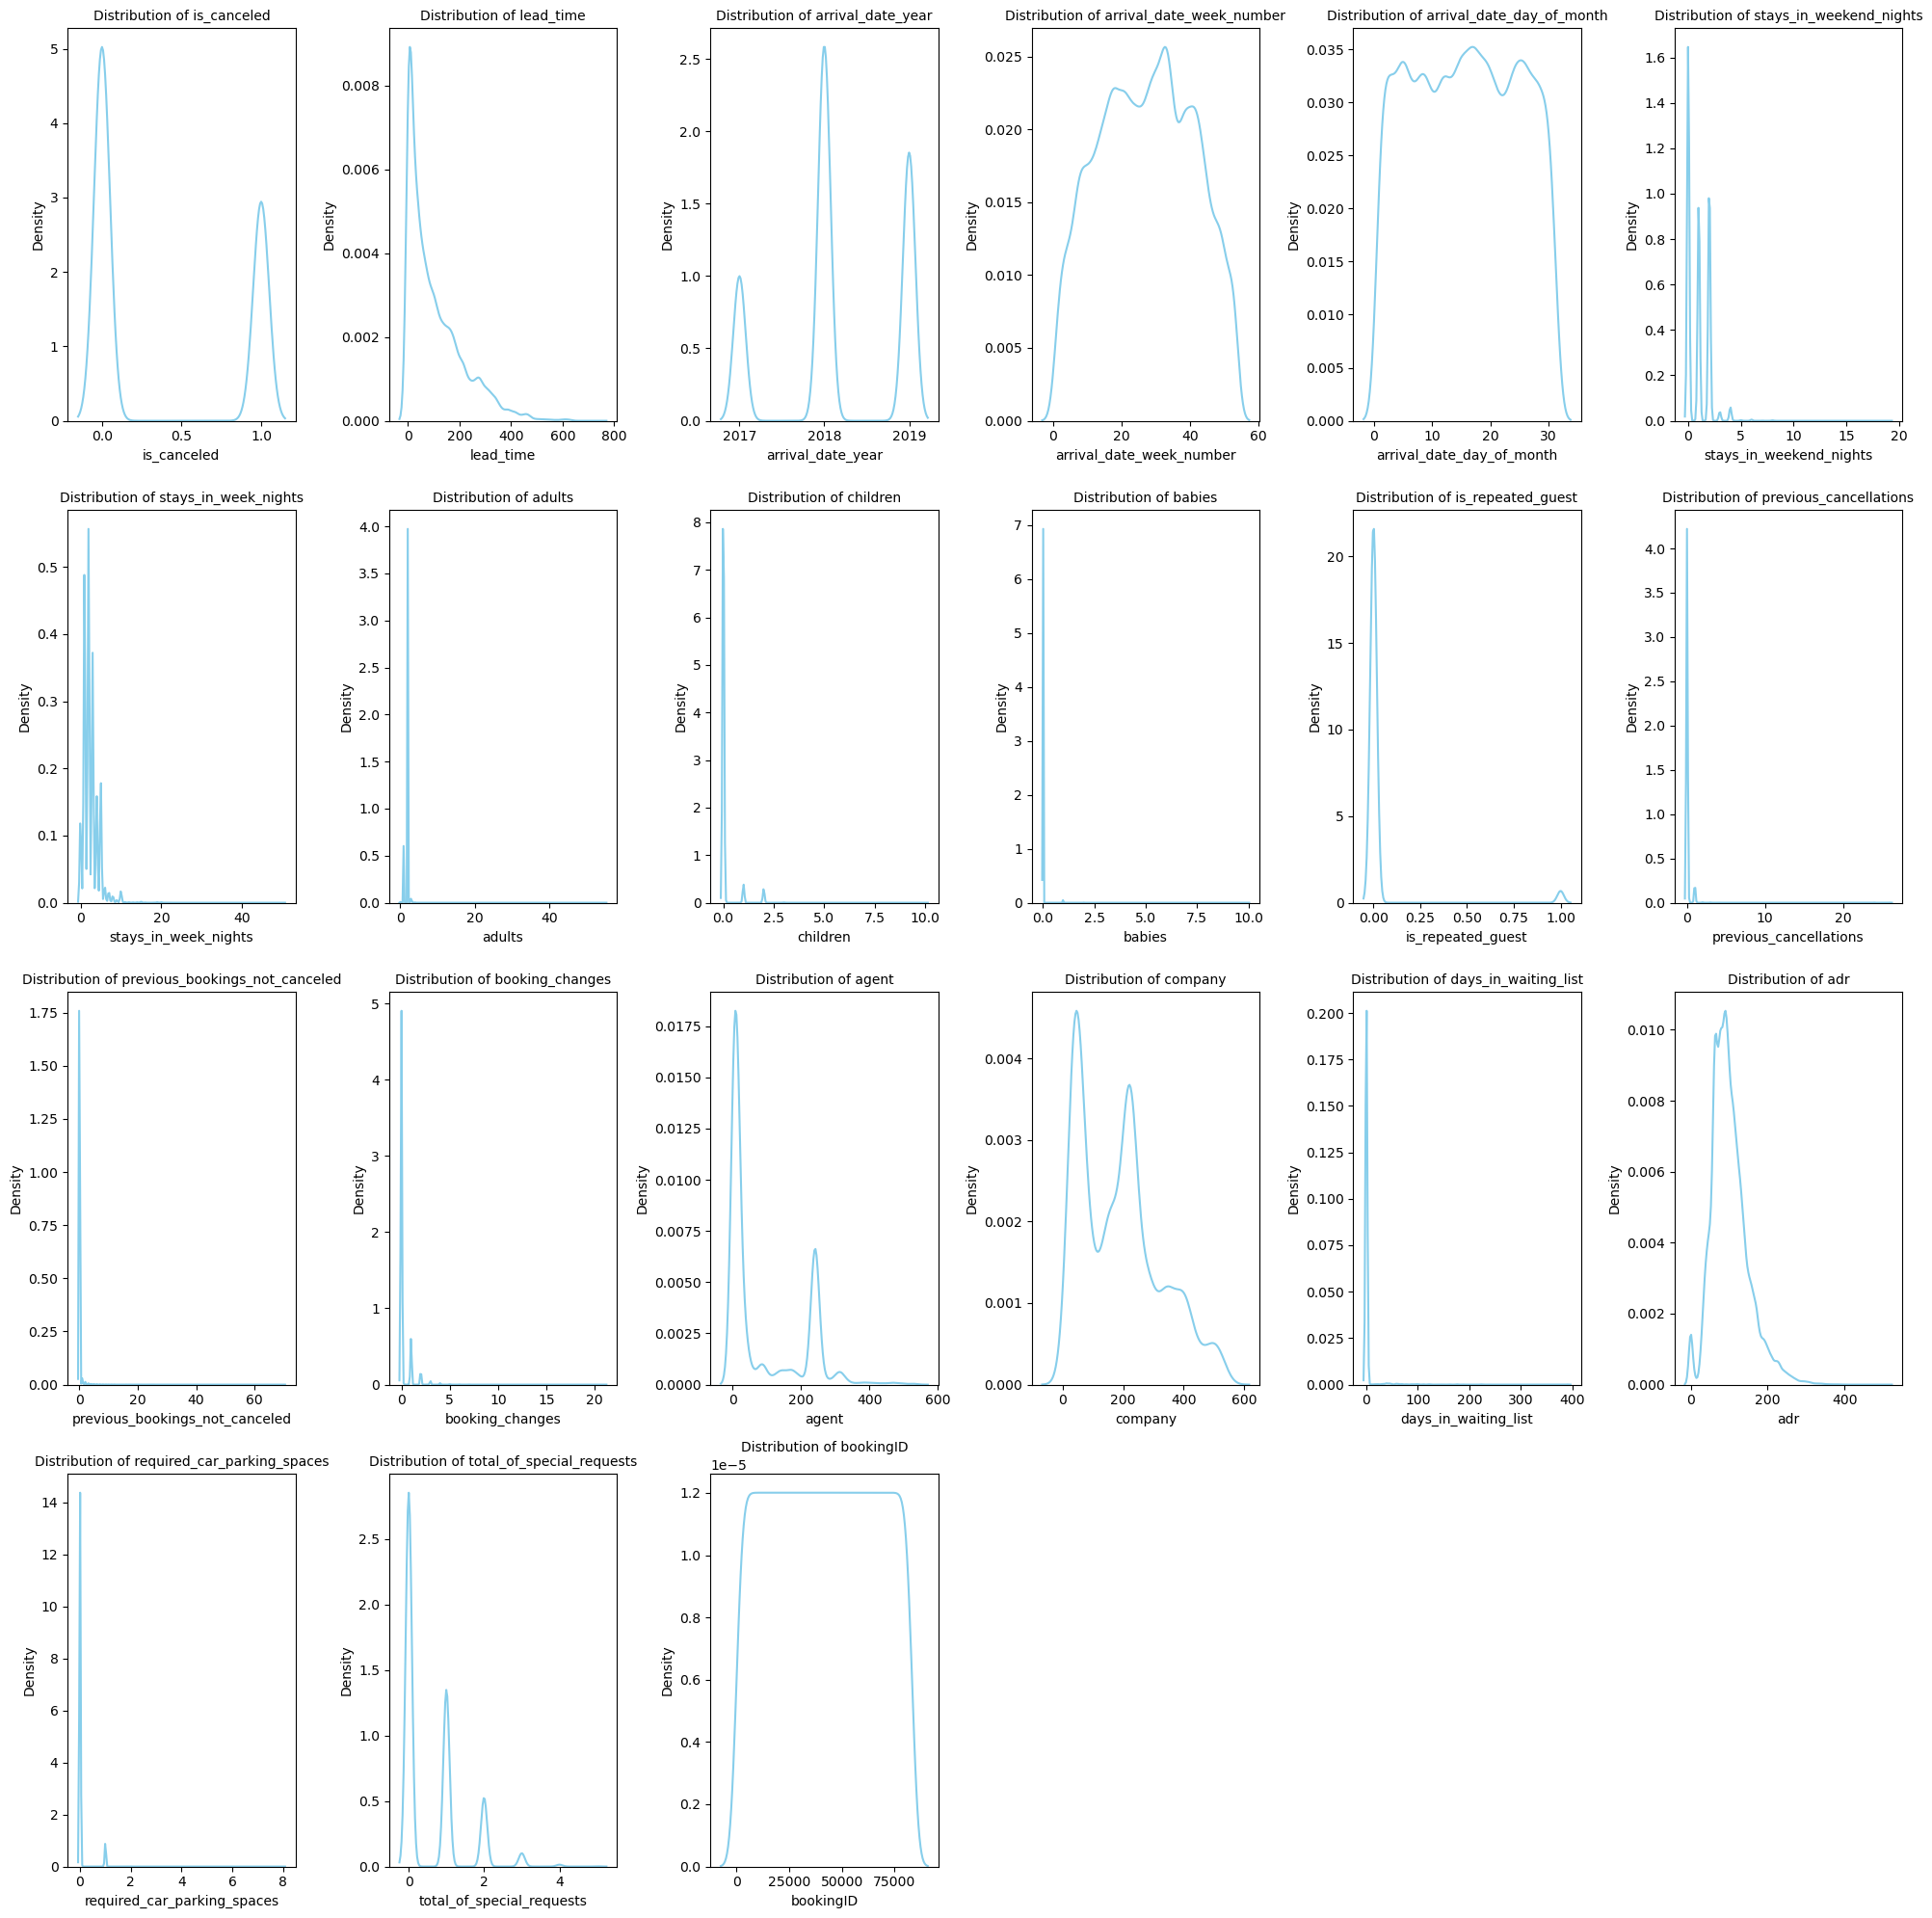

In [12]:
#distribusi for all numericals
n_cols=6
n_rows=(len(numericals)+n_cols-1)//n_cols
plt.figure(figsize=(20,5*n_rows))

for i, col in enumerate(numericals):
    plt.subplot(n_rows, n_cols, i+1)
    sns.kdeplot(x=df[col], color='skyblue')
    plt.xlabel(col)
    plt.title(f'Distribution of {col}', fontsize=10)

plt.tight_layout()
plt.show()

Kolom terlalu skew:
1. adults
2. babies
3. is repeated guest
4. previous cancelations
5. previous bookings not canceled
6. days in waiting list

## Bivariate Analysis

### Categorical Data

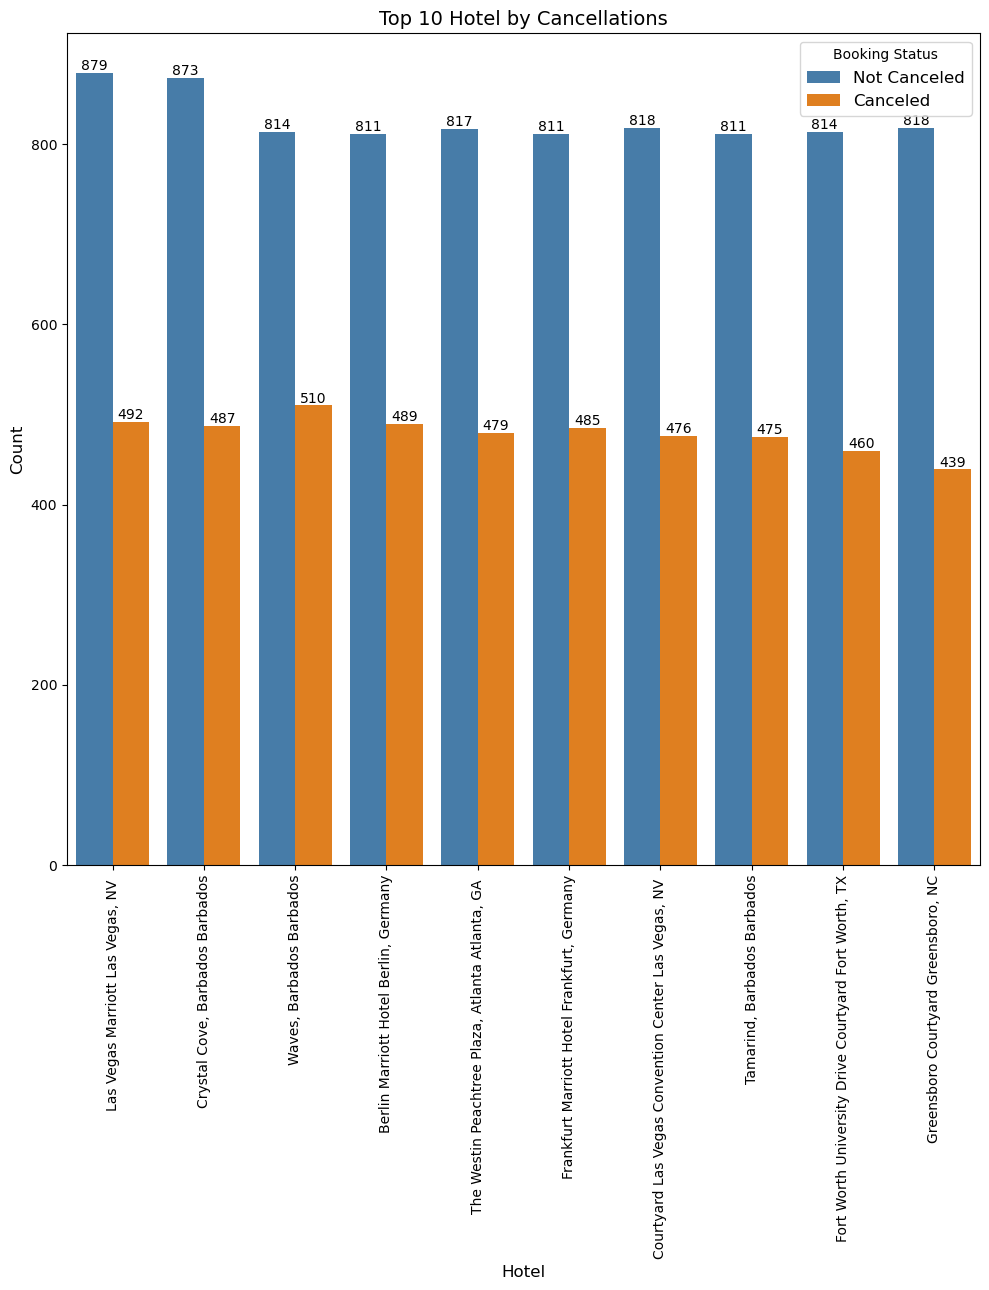

In [13]:
# Top 10 Hotel with the most reserved
top_hotel=(
    df.groupby(['hotel','is_canceled'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count',ascending=False)
)
top10_hotels=top_hotel['hotel'].value_counts().nlargest(10).index
filtered_data=df[df['hotel'].isin(top10_hotels)]

#Color bar
custom_color=['#377eb8', '#ff7f00']
# Visualisasi
plt.figure(figsize=(10,13))
ax=sns.countplot(
    x='hotel',
    hue='is_canceled',
    data=filtered_data,
    palette=custom_color,
    order=filtered_data['hotel'].value_counts().index
)

for p in ax.patches:
    if p.get_height()>0:
        ax.annotate(
            '{:.0f}'.format(p.get_height()),
            (p.get_x()+p.get_width()/2.,p.get_height()),
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            xytext=(0,5),
            textcoords='offset points'
        )
#legend
legend_labels=['Not Canceled','Canceled']
handles, _=ax.get_legend_handles_labels()
ax.legend(handles,legend_labels, title='Booking Status', fontsize=12)

ax.set_title('Top 10 Hotel by Cancellations', fontsize=14)
ax.set_xlabel('Hotel', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

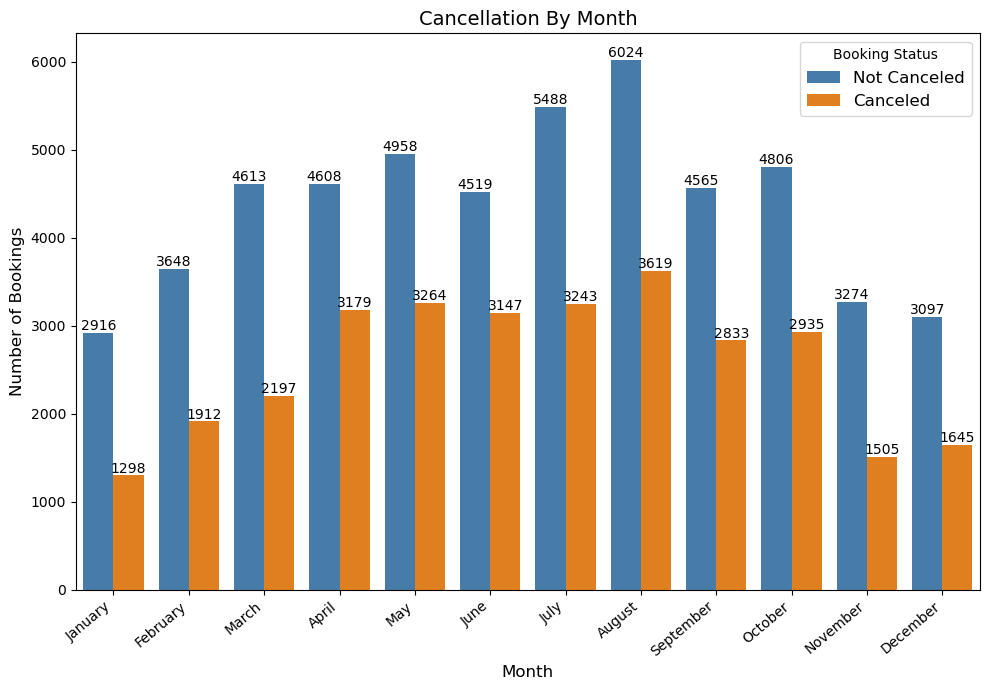

In [14]:
# arrival date month
import calendar
month_order=list(calendar.month_name[1:])
plt.figure(figsize=(10,7))
ax=sns.countplot(
    x='arrival_date_month',
    hue='is_canceled',
    data=df,
    palette=custom_color,
    order=month_order
)

for p in ax.patches:
    if p.get_height()>0:
        ax.annotate(
            '{:.0f}'.format(p.get_height()),
            (p.get_x()+p.get_width()/2.,p.get_height()),
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            xytext=(0,5),
            textcoords='offset points'
        )
#legend
ax.legend(handles,legend_labels, title='Booking Status', fontsize=12)

ax.set_title('Cancellation By Month', fontsize=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Bookings', fontsize=12)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

Hasil:
- Pada bulan Agustus paling banyak yang mereservasi dan membatalkan resevasi.
- Pulan Mei menempati posisi ke dua terbanyak yang membatalkan reservasi hotel, diikuti bulan juli

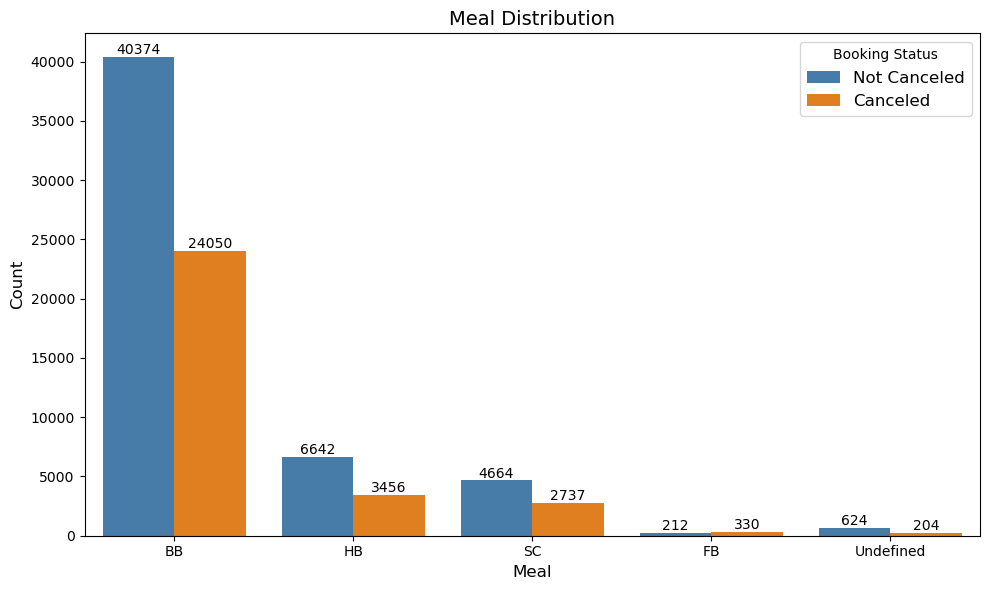

In [15]:
# Meal
plt.figure(figsize=(10,6))
ax=sns.countplot(
    x='meal',
    hue='is_canceled',
    data=df,
    palette=custom_color
)

for p in ax.patches:
    if p.get_height()>0:
        ax.annotate(
            '{:.0f}'.format(p.get_height()),
            (p.get_x()+p.get_width()/2.,p.get_height()),
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            xytext=(0,5),
            textcoords='offset points'
        )
#legend
ax.legend(handles,legend_labels, title='Booking Status', fontsize=12)

ax.set_title('Meal Distribution', fontsize=14)
ax.set_xlabel('Meal', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

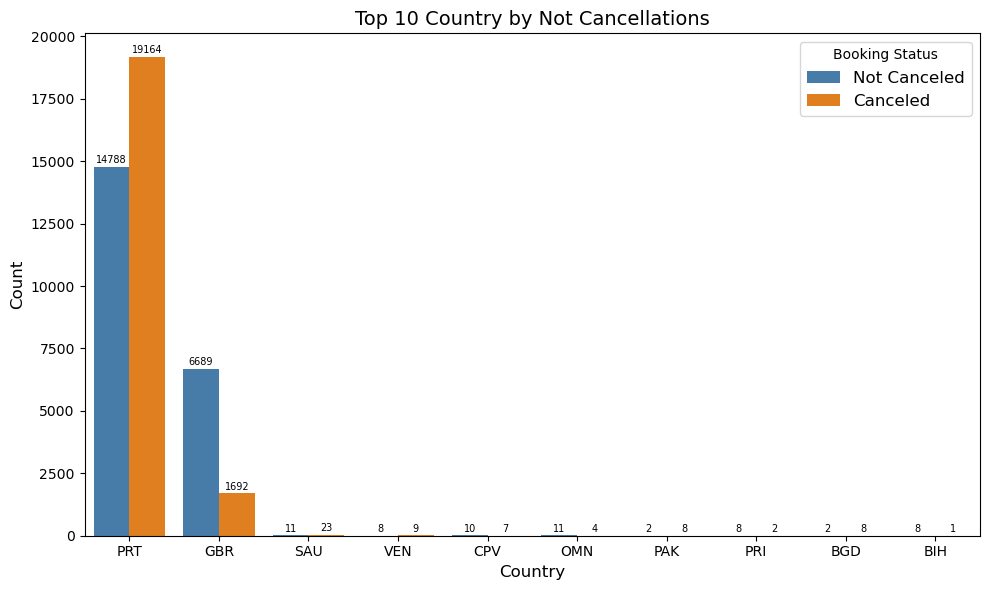

In [16]:
# Top 10 Country Not Canceled
top_country=(
    df.groupby(['country','is_canceled'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count',ascending=False)
)
top10_hotels=top_country['country'].value_counts().nlargest(10).index
filtered_country=df[df['country'].isin(top10_hotels)]

# Visualisasi
plt.figure(figsize=(10,6))
ax=sns.countplot(
    x='country',
    hue='is_canceled',
    data=filtered_country,
    palette=custom_color,
    order=filtered_country['country'].value_counts().index
)

for p in ax.patches:
    if p.get_height()>0:
        ax.annotate(
            '{:.0f}'.format(p.get_height()),
            (p.get_x()+p.get_width()/2.,p.get_height()),
            ha='center',
            va='center',
            fontsize=7,
            color='black',
            xytext=(0,5),
            textcoords='offset points'
        )
#legend
ax.legend(handles,legend_labels, title='Booking Status', fontsize=12)

ax.set_title('Top 10 Country by Not Cancellations', fontsize=14)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

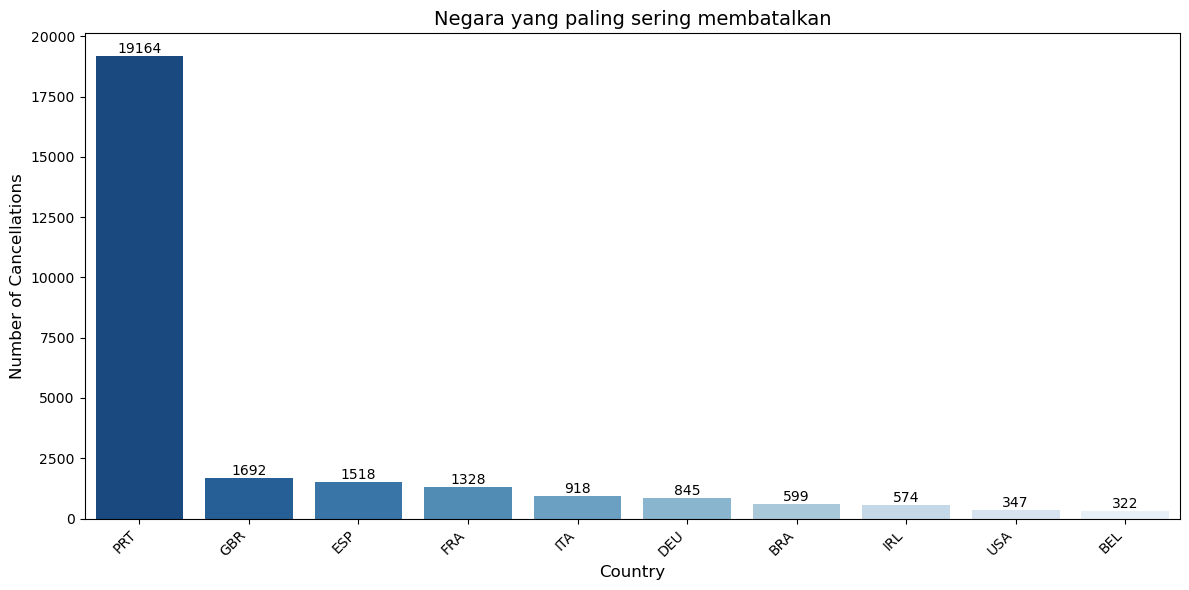

In [17]:
cancel_by_country = df.groupby('country')['is_canceled'].sum().sort_values(ascending=False).head(10)

# Visualisasi
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=cancel_by_country.index, y=cancel_by_country.values, hue=cancel_by_country.index, palette='Blues_r', legend=False)

# Label pada bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Cancellations', fontsize=12)
plt.title('Negara yang paling sering membatalkan', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

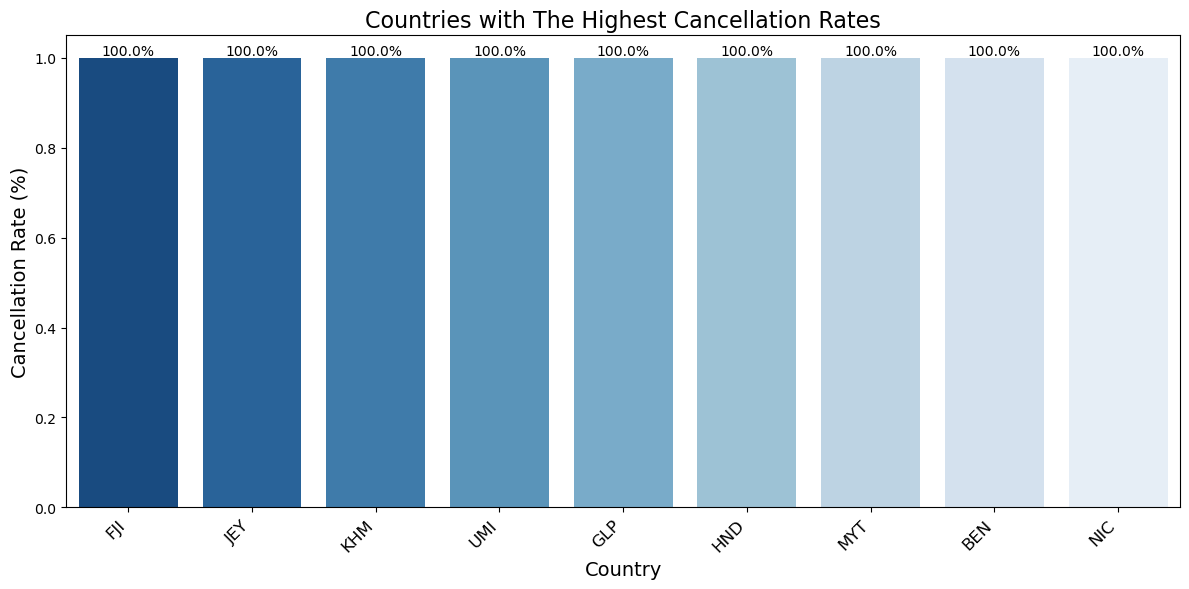

In [96]:
cancel_by_country = df.groupby('country')['is_canceled'].mean().sort_values(ascending=False).head(9)

# Visualisasi dengan palet terbalik (perbaikan)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=cancel_by_country.index, y=cancel_by_country.values, hue=cancel_by_country.index, palette='Blues_r', legend=False)

# Anotasi nilai persentase di atas bar
for p in ax.patches:
    ax.annotate(f'{p.get_height() * 100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xlabel('Country', fontsize=14)
plt.ylabel('Cancellation Rate (%)', fontsize=14)
plt.title('Countries with The Highest Cancellation Rates', fontsize=16)
plt.xticks(rotation=45, ha='right',fontsize=12)
plt.tight_layout()
plt.show()

Hasilnya:
- Beberapa negara memiliki tingkat pembatalan mencapai 100%, yang berarti semua pemesanan di negara-negara tersebut dibatalkan
- Negara HKG memeiliki tingkat pembatalan 90,9% dari total pemesanan di negara tersebut dibatalkan.
- Ada 9 negara yang semua pemesanan di negara-negara tersebut dibatalkan

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3592\41456033.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loyalty_by_country.index, y=loyalty_by_country["loyalty_percentage"], palette="coolwarm")


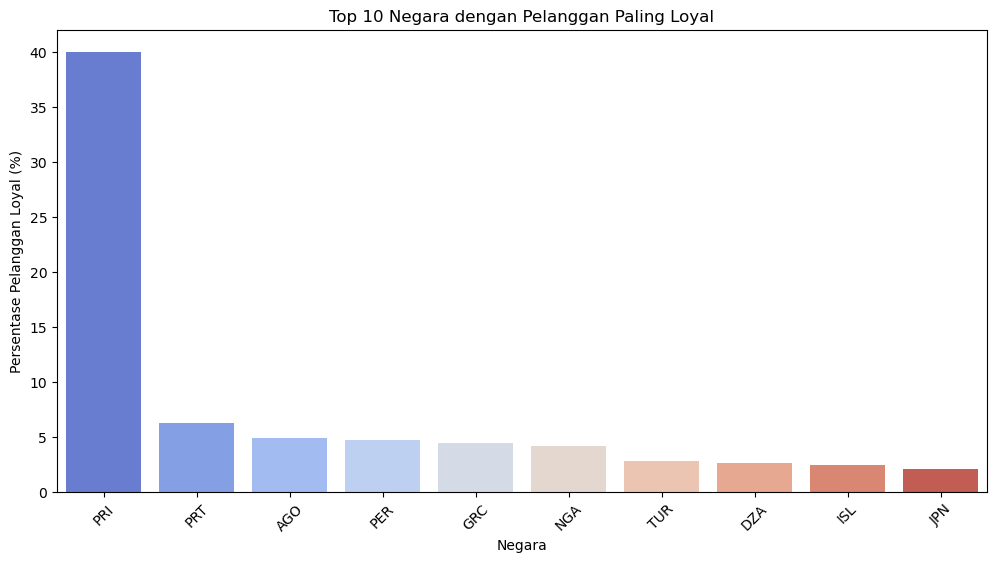

In [19]:
# Hitung total pelanggan dan pelanggan loyal per negara
loyalty_by_country = df.groupby("country")["is_repeated_guest"].agg(['sum', 'count'])
loyalty_by_country["loyalty_percentage"] = (loyalty_by_country["sum"] / loyalty_by_country["count"]) * 100

# Urutkan berdasarkan persentase loyalitas tertinggi
loyalty_by_country = loyalty_by_country.sort_values("loyalty_percentage", ascending=False).head(10)  # Top 10 negara

# Visualisasi
plt.figure(figsize=(12,6))
sns.barplot(x=loyalty_by_country.index, y=loyalty_by_country["loyalty_percentage"], palette="coolwarm")
plt.xlabel("Negara")
plt.ylabel("Persentase Pelanggan Loyal (%)")
plt.title("Top 10 Negara dengan Pelanggan Paling Loyal")
plt.xticks(rotation=45)
plt.show()

In [20]:
# 1. Negara dengan Tingkat Pembatalan Tertinggi
# Menghitung tingkat pembatalan untuk setiap negara
cancel_rate_by_country = df.groupby('country')['is_canceled'].mean()

# Mengurutkan negara berdasarkan tingkat pembatalan tertinggi
highest_cancel_rate_country = cancel_rate_by_country.sort_values(ascending=False)

# Menampilkan negara dengan tingkat pembatalan tertinggi
print("Negara dengan tingkat pembatalan tertinggi:")
print(highest_cancel_rate_country.head(1))  # Menampilkan 1 teratas

# 2. Negara yang Paling Sering Membatalkan
# Menghitung jumlah total pembatalan untuk setiap negara
total_cancels_by_country = df[df['is_canceled'] == 1]['country'].value_counts()

# Mengurutkan negara berdasarkan jumlah total pembatalan
most_cancelling_country = total_cancels_by_country.sort_values(ascending=False)

# Menampilkan negara yang paling sering membatalkan
print("\nNegara yang paling sering membatalkan:")
print(most_cancelling_country.head(1))  # Menampilkan 1 teratas

# Jika Anda ingin melihat 10 negara teratas untuk masing-masing:
print("\n10 Negara dengan tingkat pembatalan tertinggi:")
print(highest_cancel_rate_country.head(10))

print("\n10 Negara yang paling sering membatalkan:")
print(most_cancelling_country.head(10))


Negara dengan tingkat pembatalan tertinggi:
country
FJI    1.0
Name: is_canceled, dtype: float64

Negara yang paling sering membatalkan:
country
PRT    19164
Name: count, dtype: int64

10 Negara dengan tingkat pembatalan tertinggi:
country
FJI    1.000000
JEY    1.000000
KHM    1.000000
UMI    1.000000
GLP    1.000000
HND    1.000000
MYT    1.000000
BEN    1.000000
NIC    1.000000
MAC    0.933333
Name: is_canceled, dtype: float64

10 Negara yang paling sering membatalkan:
country
PRT    19164
GBR     1692
ESP     1518
FRA     1328
ITA      918
DEU      845
BRA      599
IRL      574
USA      347
BEL      322
Name: count, dtype: int64


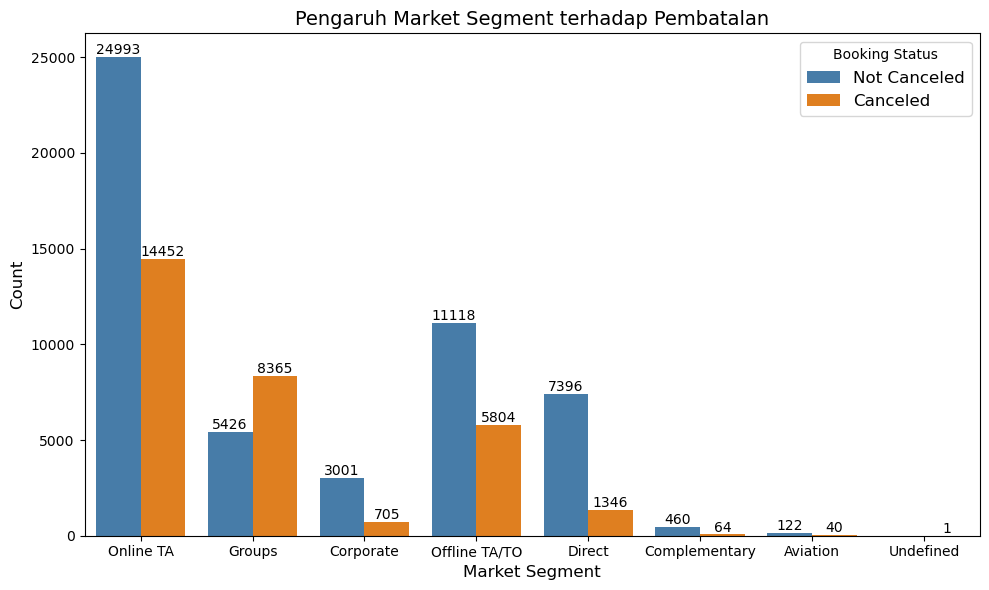

In [21]:
# Market_segment
plt.figure(figsize=(10,6))
ax=sns.countplot(
    x='market_segment',
    hue='is_canceled',
    data=df,
    palette=custom_color
)

for p in ax.patches:
    if p.get_height()>0:
        ax.annotate(
            '{:.0f}'.format(p.get_height()),
            (p.get_x()+p.get_width()/ 2., p.get_height()),
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            xytext=(0,5),
            textcoords='offset points'
        )
#legend
ax.legend(handles,legend_labels, title='Booking Status', fontsize=12)

ax.set_title('Pengaruh Market Segment terhadap Pembatalan', fontsize=14)
ax.set_xlabel('Market Segment', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

Hasilnya:
- Segment group memiliki tingkat pembatalan tinggi dibandingkan reservasi, ini menunjukkan reservasi group lebih rentan terhadap perubahan rencana atau canceled
- Segmen pasar Online TA mendominasi jumlah pemesanan, menunjukkan popularitas pemesanan online di kalangan customer. Selain itu Online TA juga termasuk tingkat canceled tertinggi
- Corporate: Segmen ini memiliki tingkat pembatalan yang sangat rendah.
- Direct: Segmen ini juga memiliki tingkat pembatalan yang relatif rendah.

Kesimpulan Awal:
- market_segment tampaknya memiliki pengaruh yang signifikan terhadap tingkat pembatalan.
- Segmen Online TA dan Groups memiliki tingkat pembatalan yang lebih tinggi, sementara segmen Corporate dan Direct memiliki tingkat pembatalan yang lebih rendah.

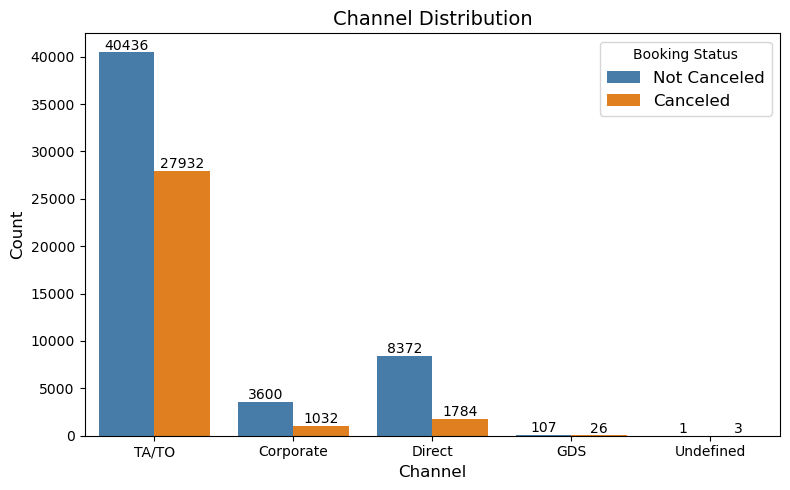

In [22]:
# Distribution_chanel

plt.figure(figsize=(8,5))
ax=sns.countplot(
    x='distribution_channel',
    hue='is_canceled',
    data=df,
    palette=custom_color
)

for p in ax.patches:
    if p.get_height()>0:
        ax.annotate(
            '{:.0f}'.format(p.get_height()),
            (p.get_x()+p.get_width()/ 2., p.get_height()),
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            xytext=(0,5),
            textcoords='offset points'
        )
#legend
ax.legend(handles,legend_labels, title='Booking Status', fontsize=12)

ax.set_title('Channel Distribution', fontsize=14)
ax.set_xlabel('Channel', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

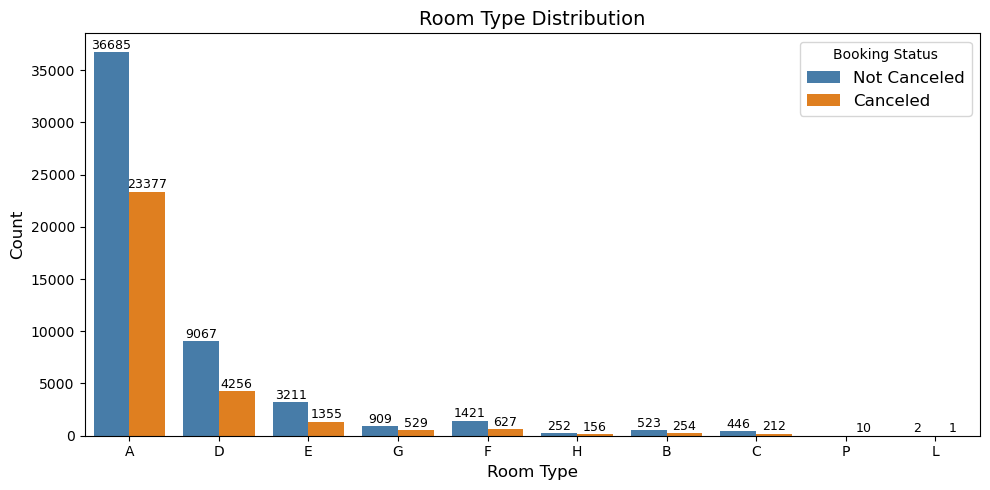

In [23]:
#reserved_room_type

plt.figure(figsize=(10,5))
ax=sns.countplot(
    x='reserved_room_type',
    hue='is_canceled',
    data=df,
    palette=custom_color
)

for p in ax.patches:
    if p.get_height()>0:
        ax.annotate(
            '{:.0f}'.format(p.get_height()),
            (p.get_x()+p.get_width()/ 2., p.get_height()),
            ha='center',
            va='center',
            fontsize=9,
            color='black',
            xytext=(0,5),
            textcoords='offset points'
        )
#legend
ax.legend(handles,legend_labels, title='Booking Status', fontsize=12)

ax.set_title('Room Type Distribution', fontsize=14)
ax.set_xlabel('Room Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

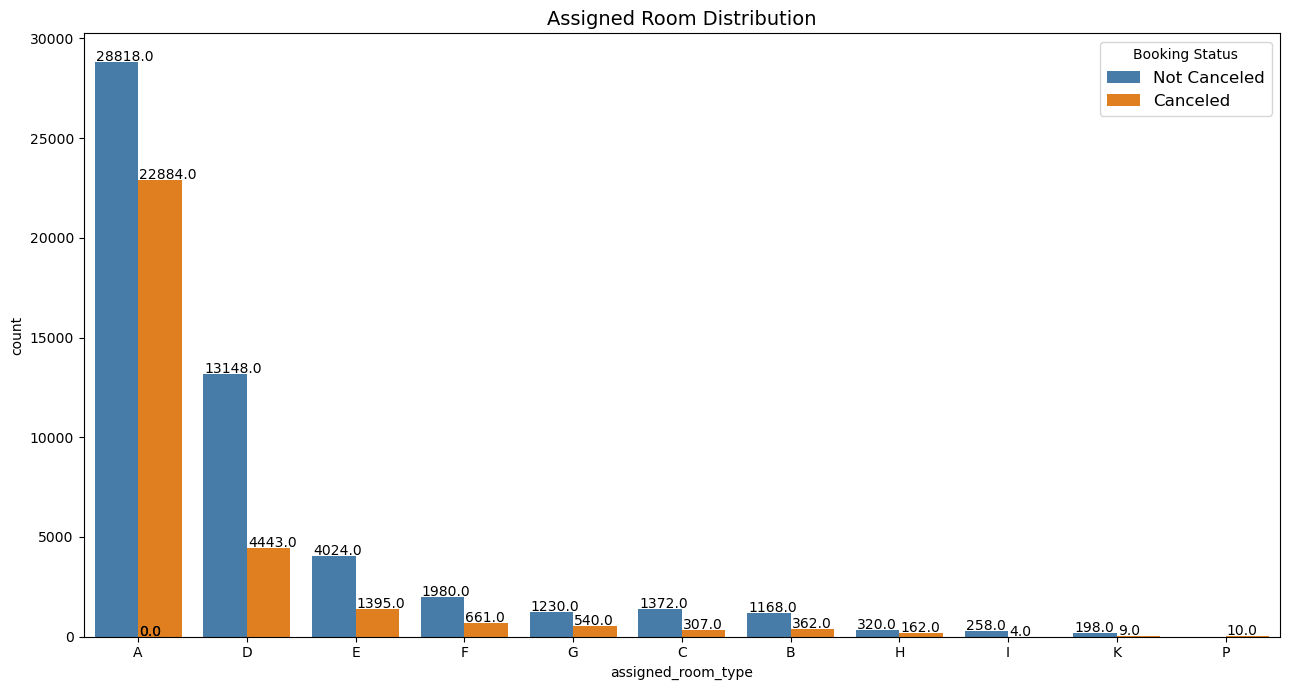

In [24]:
# assigned_room_type
plt.figure(figsize=(13,7))
ax = sns.countplot(x='assigned_room_type', hue='is_canceled', palette=custom_color, data=df, order=df['assigned_room_type'].value_counts().index)

# Set the rotation and alignment of the x-axis labels after setting fixed ticks
ax.set_xticks(range(len(ax.get_xticklabels())))  # Ensure ticks are fixed
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

# Add the count on top of each bar
for p in ax.patches:
    ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x() + 0.01, p.get_height() + 50))
#legend
ax.legend(handles,legend_labels, title='Booking Status', fontsize=12)
# Adjust layout
ax.set_title('Assigned Room Distribution', fontsize=14)
plt.tight_layout()
plt.show()


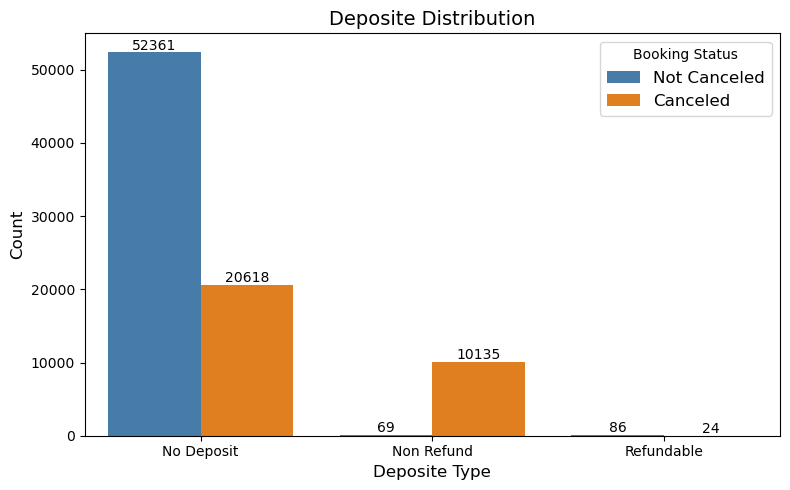

In [25]:
# deposit_type

plt.figure(figsize=(8,5))
ax=sns.countplot(
    x='deposit_type',
    hue='is_canceled',
    data=df,
    palette=custom_color
)

for p in ax.patches:
    if p.get_height()>0:
        ax.annotate(
            '{:.0f}'.format(p.get_height()),
            (p.get_x()+p.get_width()/ 2., p.get_height()),
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            xytext=(0,5),
            textcoords='offset points'
        )
#legend
ax.legend(handles,legend_labels, title='Booking Status', fontsize=12)

ax.set_title('Deposite Distribution', fontsize=14)
ax.set_xlabel('Deposite Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

Hasilnya:
- Sebagian besar customer lebih memilih tidak memberikan deposit saat melakukan reservasi
- reservasi tanpa deposit memiliki tingkat pembatalan yang cukup tinggi, tetapi jumlah pemesanan yang tidak dibatalkan masih jauh lebih besar. 
- Reservasi dengan tipe deposit "Non refund" sangat rentan untuk dibatalkan.
- Reservasi dengan deposit "refund" memiliki tingkat pembatalan yang sangat rendah.

Kesimpulan:
- Jenis deposit memiliki pengaruh terhadap pembatalan pemesanan.


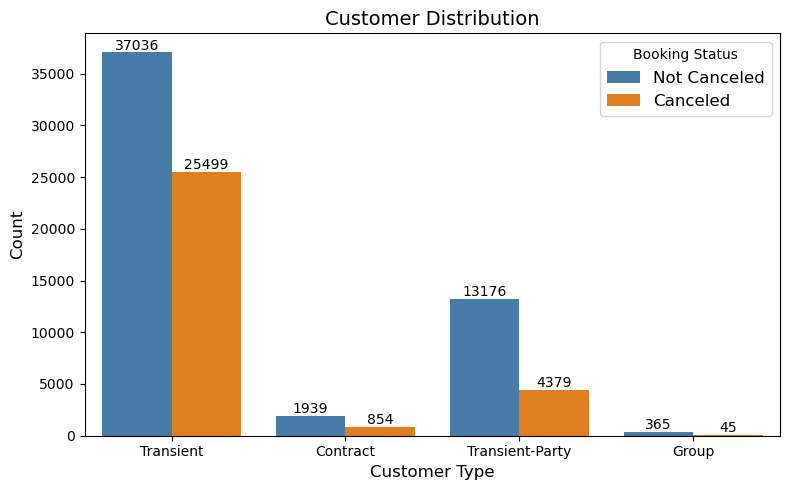

In [26]:
# customer_type
plt.figure(figsize=(8,5))
ax=sns.countplot(
    x='customer_type',
    hue='is_canceled',
    data=df,
    palette=custom_color
)

for p in ax.patches:
    if p.get_height()>0:
        ax.annotate(
            '{:.0f}'.format(p.get_height()),
            (p.get_x()+p.get_width()/ 2., p.get_height()),
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            xytext=(0,5),
            textcoords='offset points'
        )
#legend
ax.legend(handles,legend_labels, title='Booking Status', fontsize=12)

ax.set_title('Customer Distribution', fontsize=14)
ax.set_xlabel('Customer Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

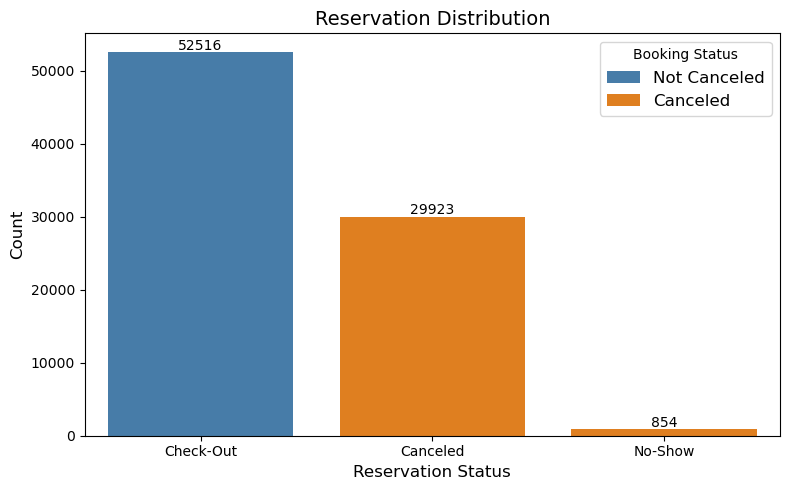

In [27]:
# reservation_status

plt.figure(figsize=(8,5))
ax=sns.countplot(
    x='reservation_status',
    hue='is_canceled',
    data=df,
    palette=custom_color
)

for p in ax.patches:
    if p.get_height()>0:
        ax.annotate(
            '{:.0f}'.format(p.get_height()),
            (p.get_x()+p.get_width()/ 2., p.get_height()),
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            xytext=(0,5),
            textcoords='offset points'
        )
#legend
ax.legend(handles,legend_labels, title='Booking Status', fontsize=12)

ax.set_title('Reservation Distribution', fontsize=14)
ax.set_xlabel('Reservation Status', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

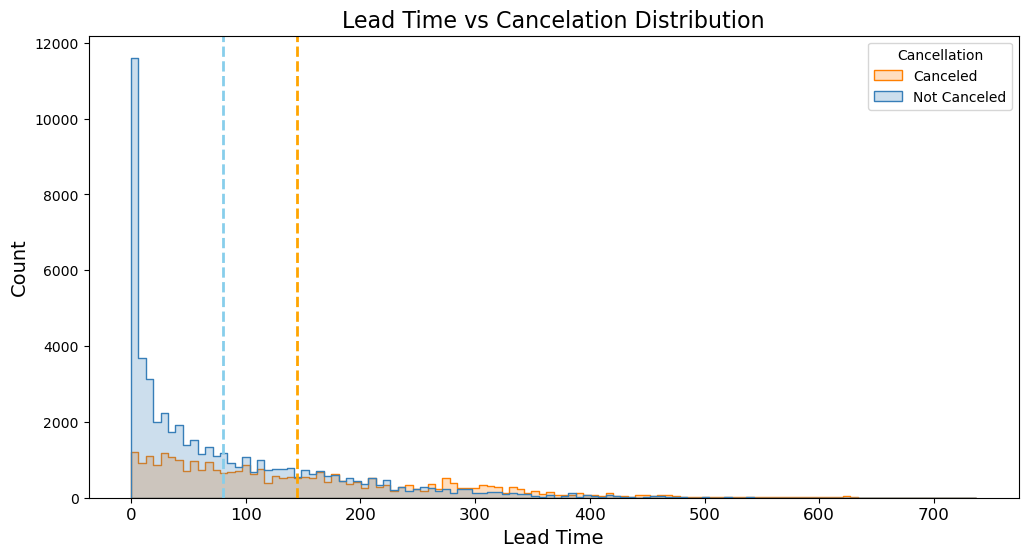

In [97]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='lead_time', hue='is_canceled', element='step', palette=custom_palette, common_norm=False)

# Hitung rata-rata lead_time untuk setiap kategori pembatalan
mean_canceled = df[df['is_canceled'] == 1]['lead_time'].mean()
mean_not_canceled = df[df['is_canceled'] == 0]['lead_time'].mean()

# Tambahkan garis vertikal untuk rata-rata
plt.axvline(mean_canceled, color='orange', linestyle='--', linewidth=2, label=f'Rata-rata Canceled: {mean_canceled:.2f}')
plt.axvline(mean_not_canceled, color='skyblue', linestyle='--', linewidth=2, label=f'Rata-rata Not Canceled: {mean_not_canceled:.2f}')


plt.legend(title='Cancellation', labels=['Canceled','Not Canceled']) # Perbaikan disini
plt.title("Lead Time vs Cancelation Distribution", fontsize=16)
plt.xlabel('Lead Time', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.show()

Hasilnya:
- Canceled pemesanan cendrung pada distibusi lead time yang panjang
- Sebagian besar reservasi memiliki lead time dibawah 100 hari
- pemesanan dengan lead_time yang lebih lama cenderung lebih rentan terhadap pembatalan.
- Rata-rata lead time untuk pemesanan yang dibatalkan (garis oranye) lebih tinggi daripada rata-rata lead time untuk pemesanan yang tidak dibatalkan (garis biru).

Kesimpulan Awal:
- Secara umum, lead time tampaknya memiliki pengaruh terhadap pembatalan pemesanan.
- Pemesanan dengan lead time yang lebih lama cenderung lebih sering dibatalkan.

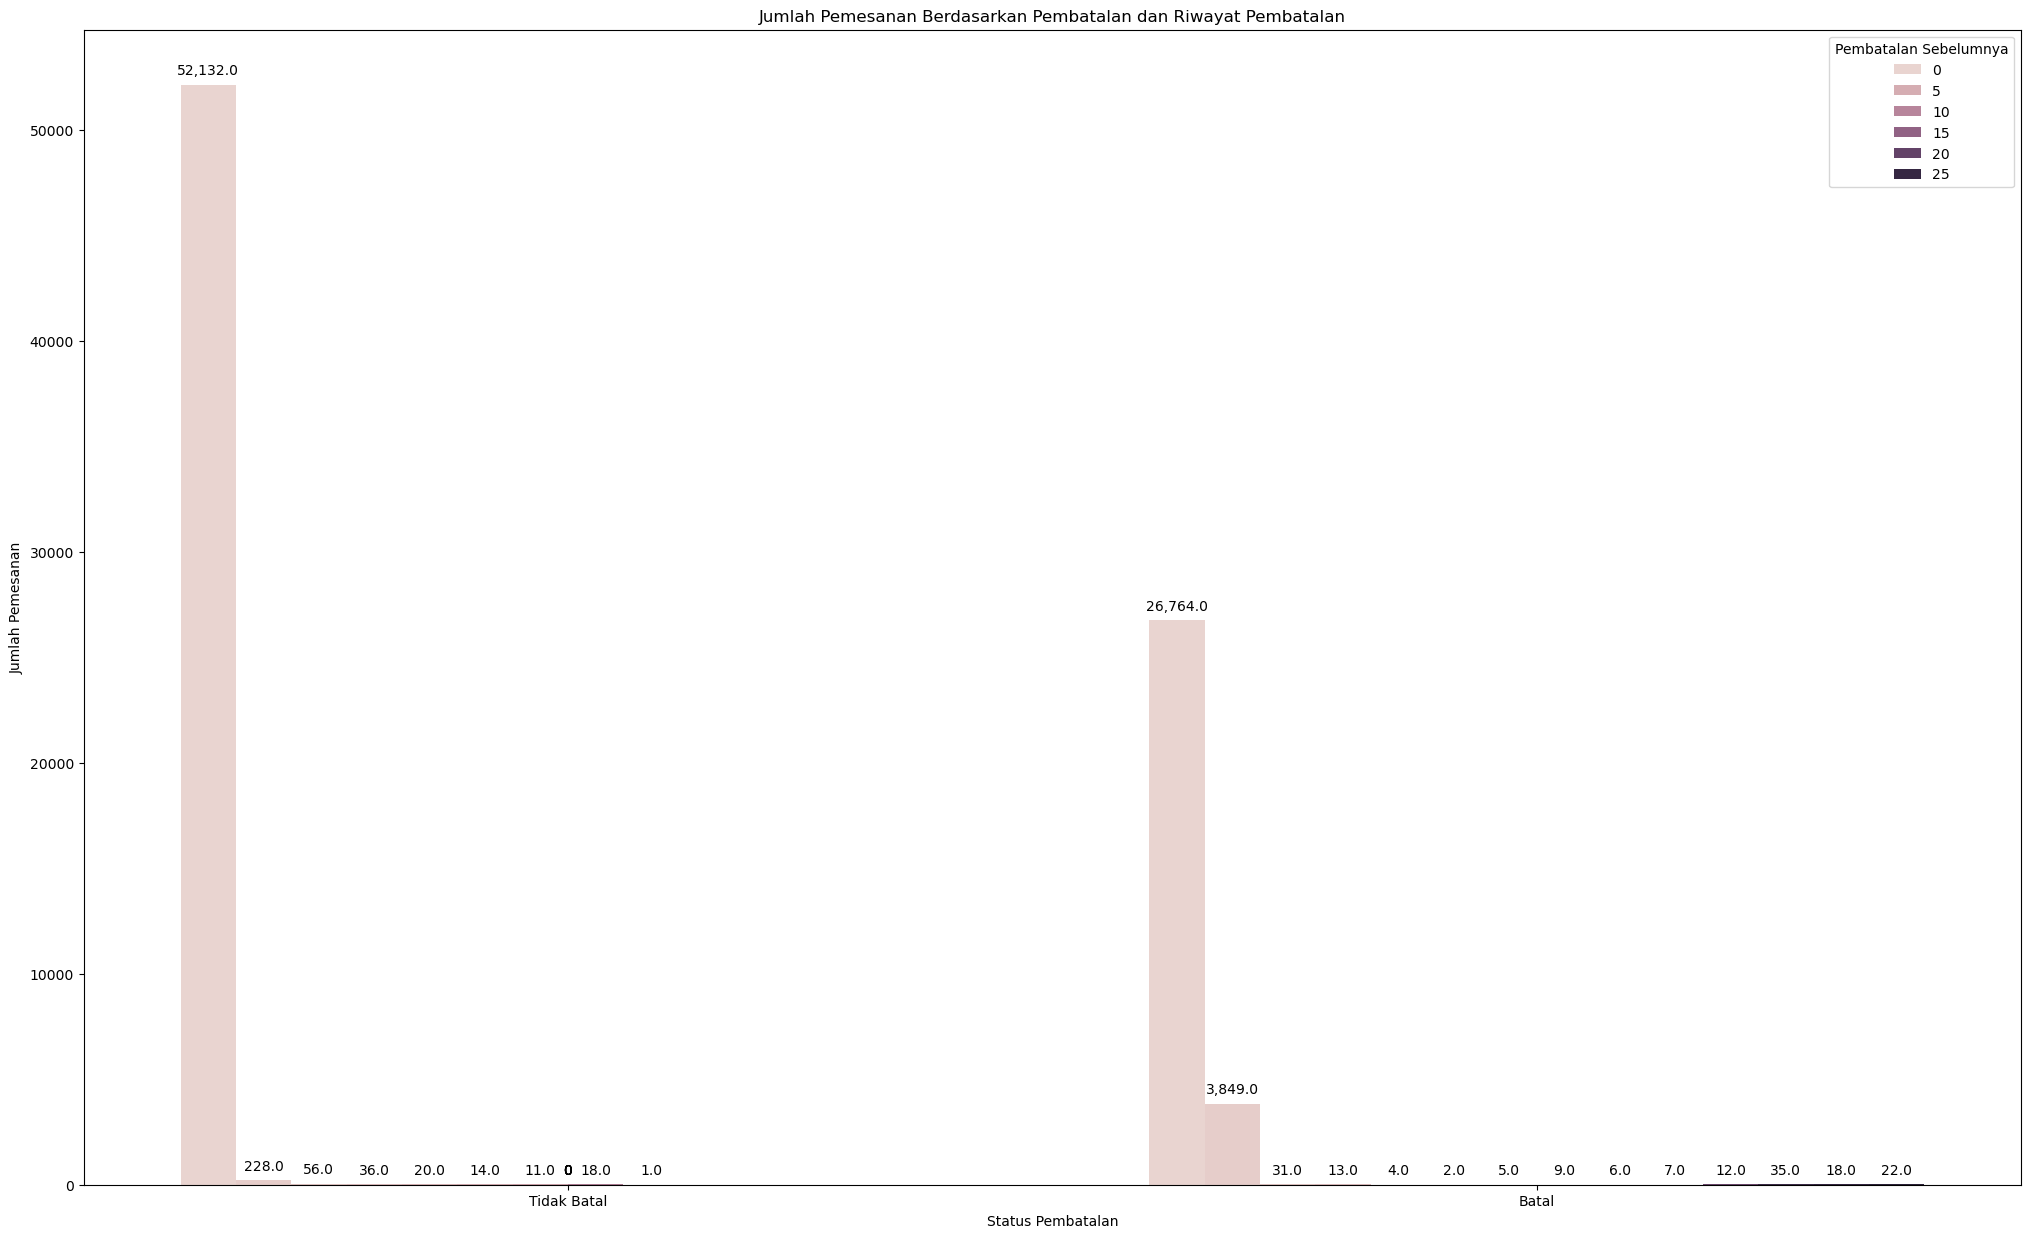

In [29]:
plt.figure(figsize=(25, 15))
# Buat grafik batang yang dikelompokkan
ax=sns.countplot(x='is_canceled', hue='previous_cancellations', data=df)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
                
plt.title('Jumlah Pemesanan Berdasarkan Pembatalan dan Riwayat Pembatalan')
plt.xlabel('Status Pembatalan')
plt.ylabel('Jumlah Pemesanan')
plt.xticks([0, 1], ['Tidak Batal', 'Batal'])
plt.legend(title='Pembatalan Sebelumnya')
plt.show()

Hasilnya:
- Sebagian besar pelanggan cendrung tidak membatalkan pesanan.
- Meskipun jumlahnya relatif kecil, terdapat pemesanan yang dibatalkan oleh tamu dengan riwayat pembatalan 5 kali.

Kesimpulan Awal:
- Tamu dengan riwayat pembatalan 0 kali memiliki kecenderungan paling rendah untuk membatalkan.
- Tamu dengan riwayat pembatalan 5 kali menunjukkan kecenderungan yang lebih tinggi untuk membatalkan dibandingkan dengan tamu yang belum pernah membatalkan.
- Tamu dengan riwayat pembatalan lebih dari 5 kali memiliki jumlah pembatalan yang sangat sedikit.

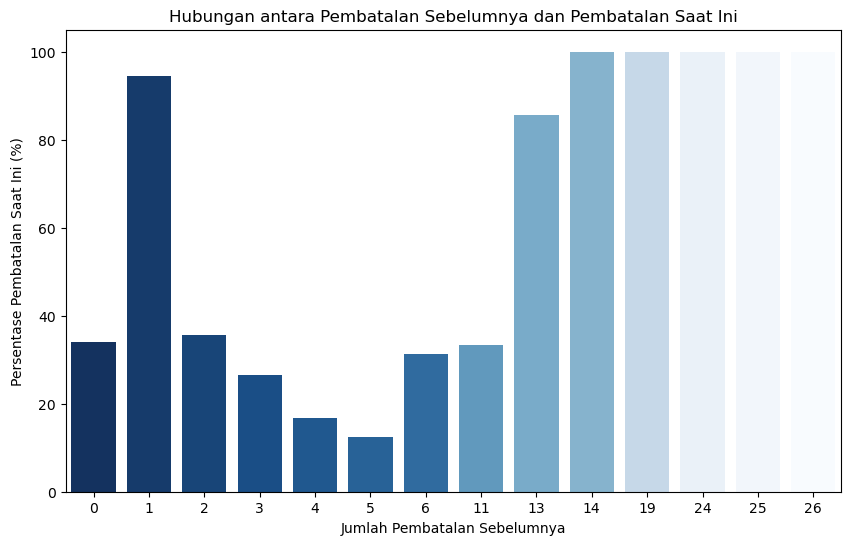

In [30]:
cancel_group = (
    df.groupby("previous_cancellations")["is_canceled"].mean() * 100
)

# Plot hasilnya
plt.figure(figsize=(10, 6))
sns.barplot(
    x=cancel_group.index,
    y=cancel_group.values,
    palette="Blues_r",
    hue=cancel_group.index,  # Tambahkan hue
    legend=False,  # Tambahkan legend=False
)
plt.xlabel("Jumlah Pembatalan Sebelumnya")
plt.ylabel("Persentase Pembatalan Saat Ini (%)")
plt.title("Hubungan antara Pembatalan Sebelumnya dan Pembatalan Saat Ini")
plt.show()

Hasilnya:
- Semakin banyak pembatalan yang dilakukan pelanggan di masa lalu, semakin tinggi kemungkinan mereka membatalkan reservasi saat ini.
- Pelanggan yang telah membatalkan banyak reservasi sebelumnya memiliki kecenderungan yang jauh lebih tinggi untuk membatalkan reservasi berikutnya dibandingkan dengan pelanggan yang tidak pernah atau jarang membatalkan.

### Numerical Data

In [31]:
def dis_bivariate(title):
    # custom_color=['#ff7f00','#377eb8']
    df_data=df.copy()
    df_data['is_canceled']=df_data['is_canceled'].replace({
        0: 'Not Cancelled',
        1: 'Cancelled'
        }
    )
    g=sns.FacetGrid(
        df_data,
        hue='is_canceled',
        palette=custom_color
    )
    g.map(sns.kdeplot, title, fill=True)
    g.add_legend()
    g.fig.suptitle(f'Distribution of {title} by Cancelllation', fontsize=12)
    g.fig.subplots_adjust(top=0.85)
    plt.show()

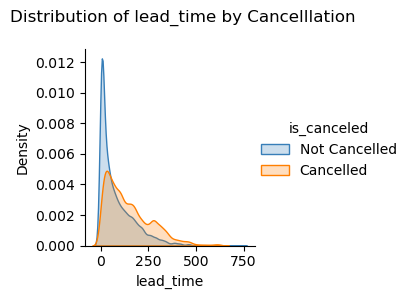

In [32]:
dis_bivariate('lead_time')

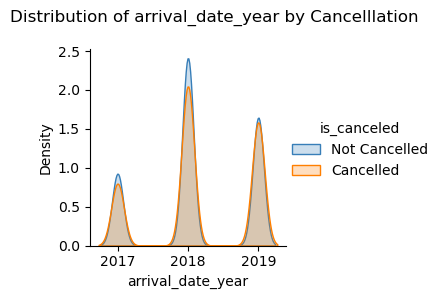

In [33]:
dis_bivariate('arrival_date_year')

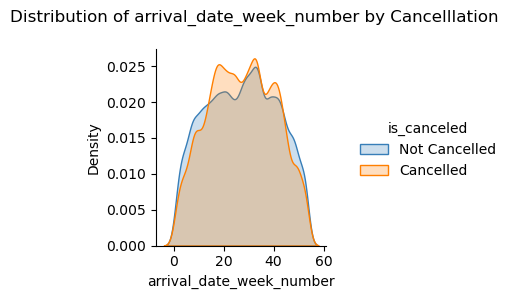

In [34]:
dis_bivariate('arrival_date_week_number')

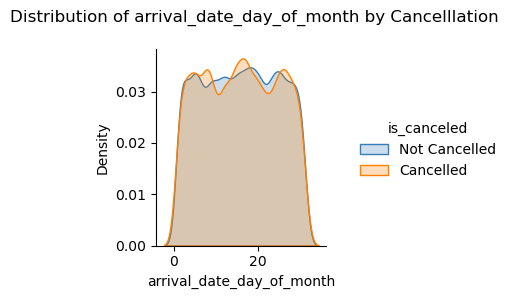

In [35]:
dis_bivariate('arrival_date_day_of_month')

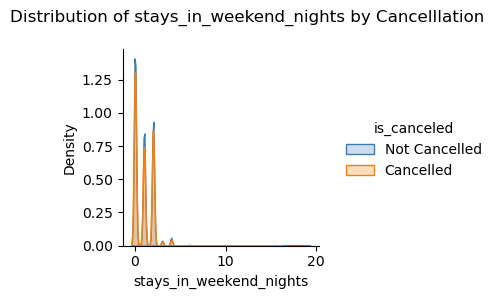

In [36]:
dis_bivariate('stays_in_weekend_nights')

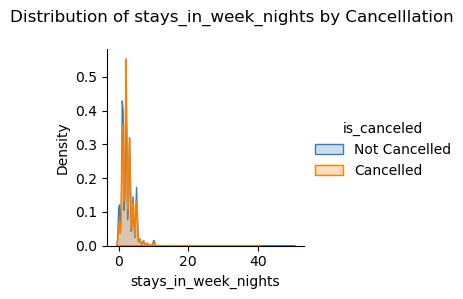

In [37]:
dis_bivariate('stays_in_week_nights')

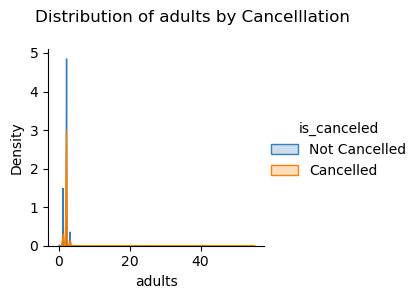

In [38]:
dis_bivariate('adults')

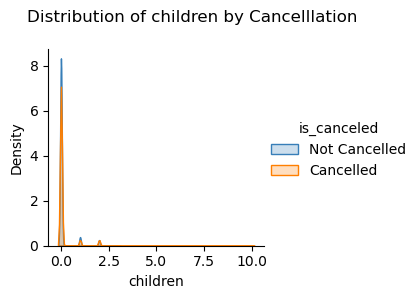

In [39]:
dis_bivariate('children')

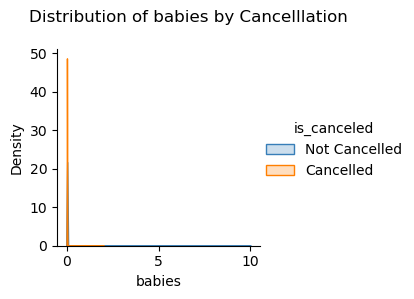

In [40]:
dis_bivariate('babies')

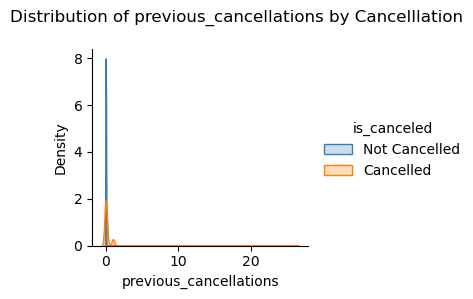

In [41]:
dis_bivariate('previous_cancellations')

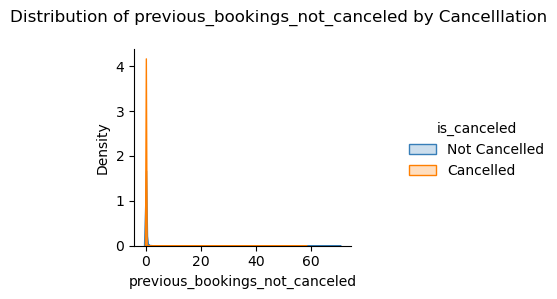

In [42]:
dis_bivariate('previous_bookings_not_canceled')

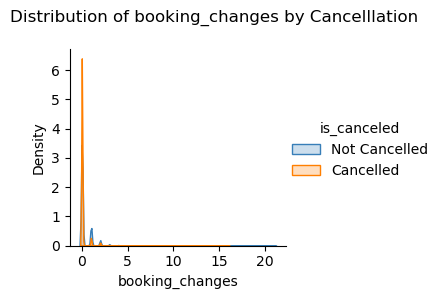

In [43]:
dis_bivariate('booking_changes')

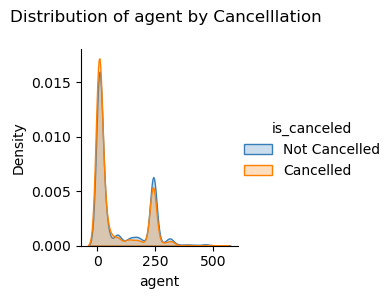

In [44]:
dis_bivariate('agent')

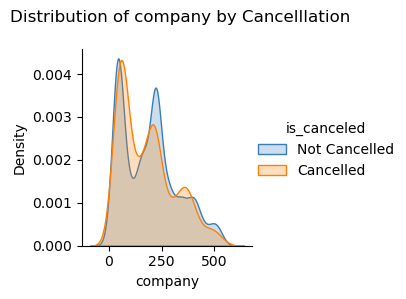

In [45]:
dis_bivariate('company')

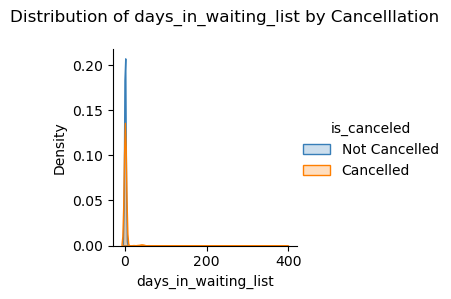

In [46]:
dis_bivariate('days_in_waiting_list')

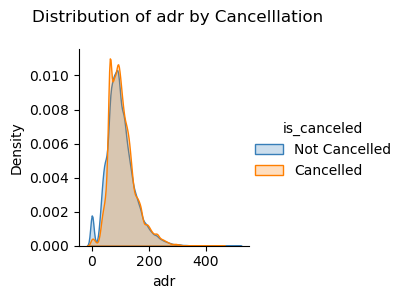

In [47]:
dis_bivariate('adr')

c:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)


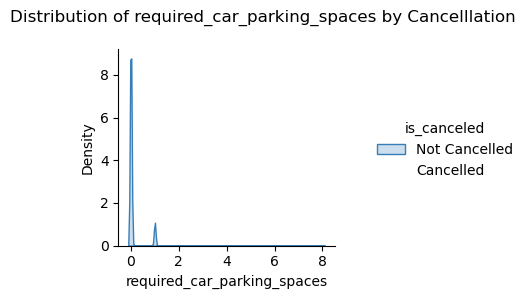

In [48]:
dis_bivariate('required_car_parking_spaces')

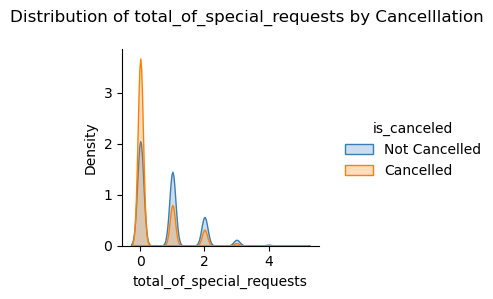

In [49]:
dis_bivariate('total_of_special_requests')

Notes:
1. reservation_status (no-show-> cancelled)
2. required_car_parking_spaces untuk yang not cancelled

## Multivariate Analysis

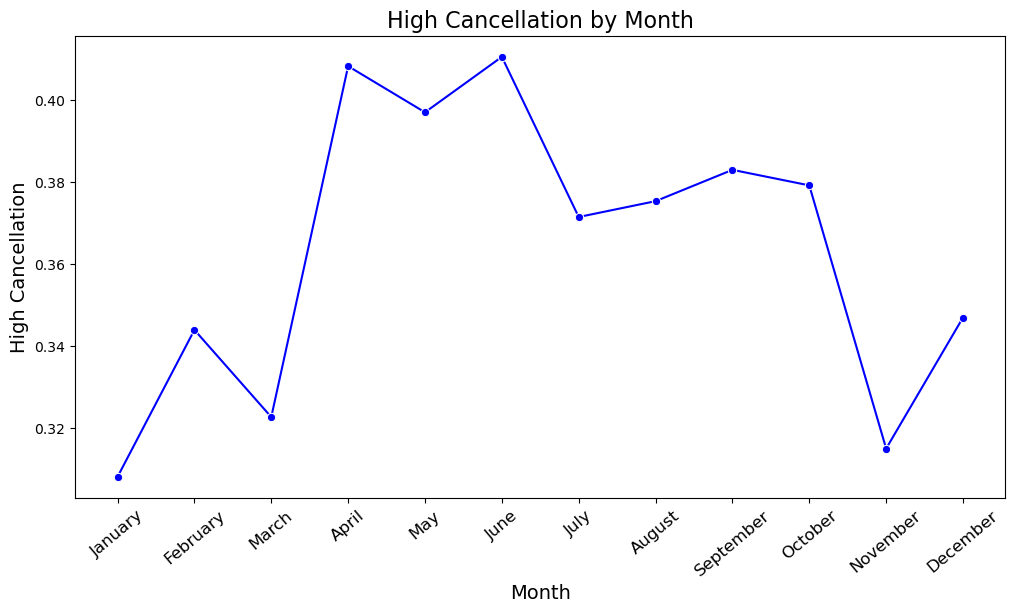

In [90]:
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"], categories=[
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"], ordered=True)

# Hitung jumlah reservasi per bulan
total_reservations_by_month = df["arrival_date_month"].value_counts().sort_index()

# Hitung jumlah pembatalan per bulan
cancelled_reservations_by_month = df[df["is_canceled"] == 1]["arrival_date_month"].value_counts().sort_index()

# Gabungkan jumlah reservasi dan jumlah pembatalan ke dalam DataFrame baru
monthly_data = pd.DataFrame({
    "Total Reservations": total_reservations_by_month,
    "Cancelled Reservations": cancelled_reservations_by_month
}).fillna(0)  # Mengisi nilai NaN dengan 0

# Hitung tingkat pembatalan
monthly_data["Cancellation Rate"] = monthly_data["Cancelled Reservations"] / monthly_data["Total Reservations"]

# Plot tingkat pembatalan
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_data.index, y=monthly_data["Cancellation Rate"], marker="o", color="b")
plt.xlabel("Month", fontsize=14)
plt.ylabel("High Cancellation",fontsize=14)
plt.title("High Cancellation by Month",fontsize=16)
plt.xticks(rotation=40,fontsize=12 )
plt.show()

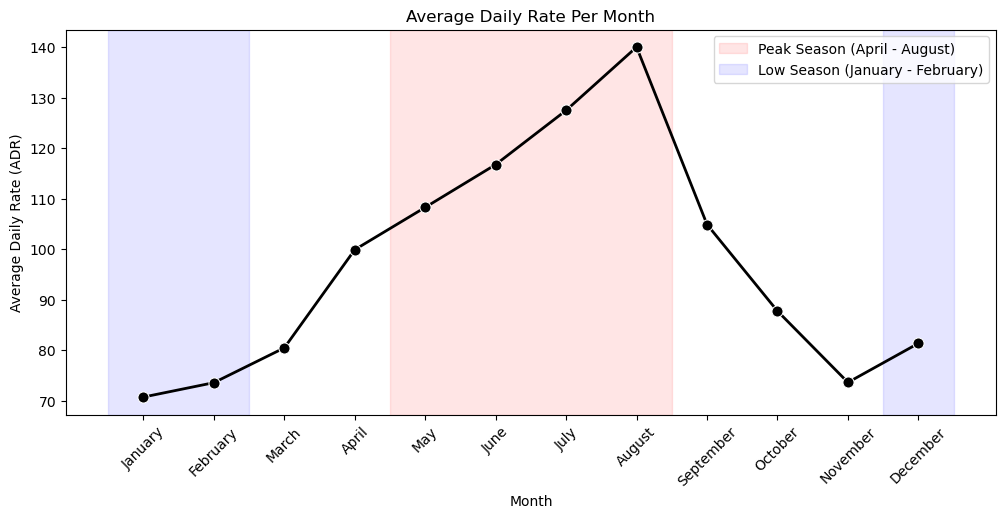

In [50]:
bulan_urut = ["January", "February", "March", "April", "May", "June",
              "July", "August", "September", "October", "November", "December"]

# Konversi ke kategori agar seaborn menampilkan urutan yang benar
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"], categories=bulan_urut, ordered=True)

# Buat plot
plt.figure(figsize=(12, 5))

# Gunakan warna berdasarkan nilai ADR (lebih tinggi = merah, lebih rendah = biru)
colors = sns.color_palette("Set2", as_cmap=True)
norm = plt.Normalize(df["adr"].min(), df["adr"].max())

# Plot dengan warna gradasi
sns.lineplot(
    x="arrival_date_month",
    y="adr",
    data=df,
    estimator=np.mean,
    errorbar=None, # Perbaikan: ganti ci dengan errorbar
    marker="o",
    markersize=8,
    color="black",
    linewidth=2
)

# Tambahkan shading untuk musim puncak
plt.axvspan(3.5, 7.5, color='red', alpha=0.1, label="Peak Season (April - August)")
plt.axvspan(-0.5, 1.5, color='blue', alpha=0.1, label="Low Season (January - February)")
plt.axvspan(10.5, 11.5, color='blue', alpha=0.1)  # Low Season (November - December)

# Tambahkan label dan judul
plt.xticks(rotation=45)
plt.ylabel("Average Daily Rate (ADR)")
plt.xlabel("Month")
plt.title("Average Daily Rate Per Month")

# Tambahkan legenda
plt.legend()

# Tampilkan plot
plt.show()


ADR untuk mengukur pendapatan rata-rata per kamar yang ditempati dalam satu hari. 
Hasilnya:
- ADR mencapai puncaknya pada bulan Agustus, dengan nilai tertinggi sekitar 140.
- ADR berada di titik terendah pada bulan Januari dan Februari, dengan nilai di bawah 80.

Saran:
- Bulan Januari dan Februari menunjukkan ADR terendah. Ini adalah periode dengan permintaan terendah, sehingga hotel perlu menurunkan harga untuk menarik pelanggan.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3592\2146641851.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='deposit_type', y='is_canceled', data=cancellation_rates,palette="Blues_r",) # palette removed


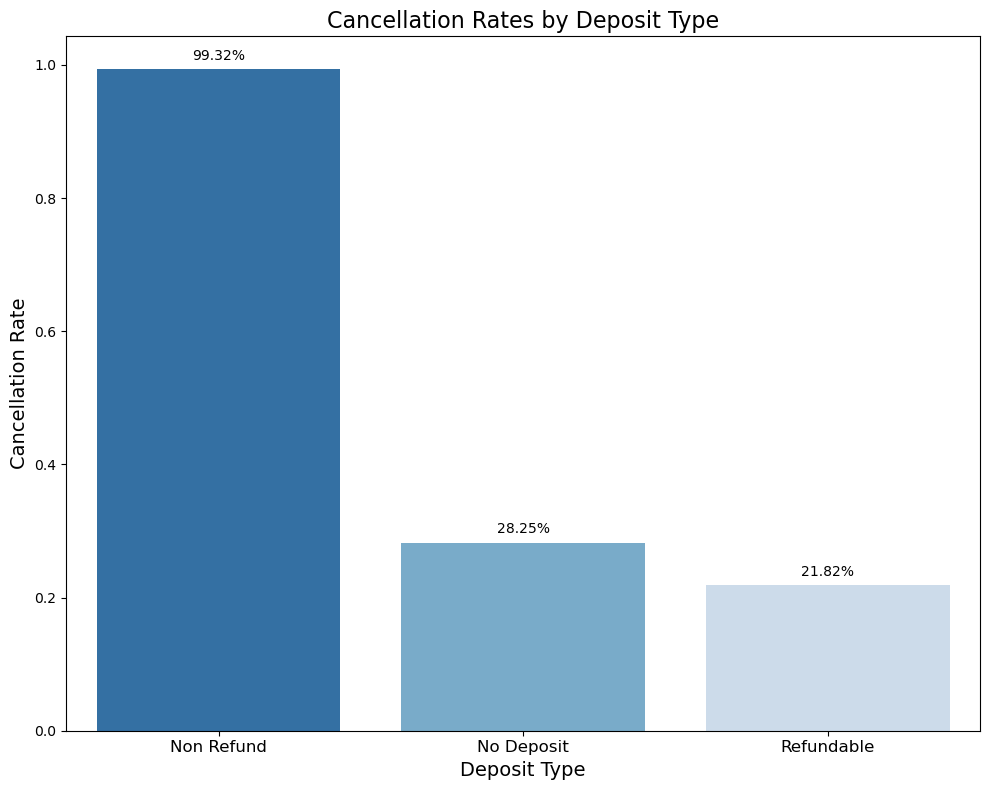

In [ ]:
# Hitung tingkat pembatalan untuk setiap jenis deposit
cancellation_rates = df.groupby('deposit_type')['is_canceled'].mean().reset_index()

# Urutkan berdasarkan tingkat pembatalan menurun
cancellation_rates = cancellation_rates.sort_values(by='is_canceled', ascending=False)

# Visualisasikan tingkat pembatalan
plt.figure(figsize=(10, 8))
ax = sns.barplot(x='deposit_type', y='is_canceled', data=cancellation_rates, palette="Blues_r") # palette removed

for p in ax.patches:
    ax.annotate(
        '{:.2%}'.format(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points'
    )

plt.title('Cancellation Rates by Deposit Type', fontsize=16)
plt.xlabel('Deposit Type', fontsize=14)
plt.ylabel('Cancellation Rate', fontsize=14)
plt.xticks(fontsize=12)
plt.tight_layout()
plt.show()

# Tampilkan jenis deposit dengan tingkat pembatalan tertinggi
highest_risk_deposit = cancellation_rates.iloc[0]['deposit_type']
highest_risk_rate = cancellation_rates.iloc[0]['is_canceled']

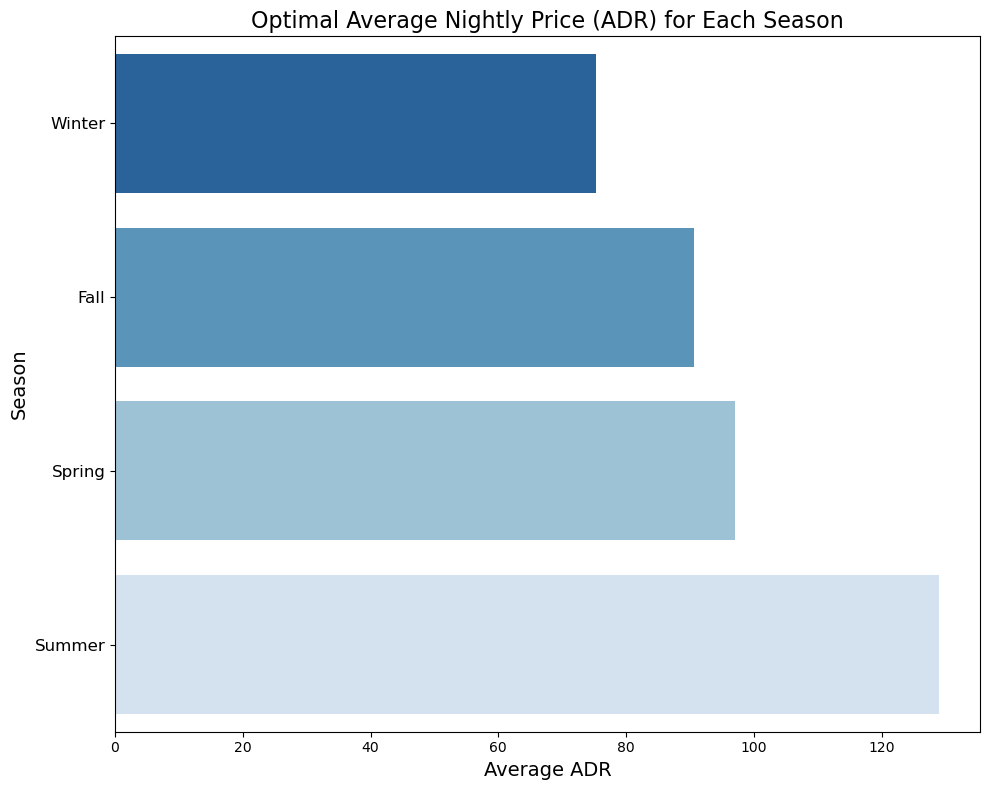

In [119]:
season_map = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Fall', 'October': 'Fall', 'November': 'Fall'
}

df["season"] = df["arrival_date_month"].map(season_map)

# Hitung rata-rata ADR per musim
adr_season = df.groupby("season")["adr"].mean().sort_values()

# Plot hasilnya (bar plot menyamping)
plt.figure(figsize=(10, 8))
ax = sns.barplot(
    y=adr_season.index,  # Tukar x dan y
    x=adr_season.values,  # Tukar x dan y
    palette="Blues_r",
    hue=adr_season.index,
    legend=False,
)


plt.ylabel("Season", fontsize=14)  # Tukar label x dan y
plt.xlabel("Average ADR", fontsize=14)  # Tukar label x dan y
plt.title("Optimal Average Nightly Price (ADR) for Each Season", fontsize=16)
plt.yticks(fontsize=12) #Tukar xticks menjadi yticks
plt.tight_layout() #menghindari label yang terpotong
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3592\2427594469.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="season", y="adr", data=df, palette="coolwarm")


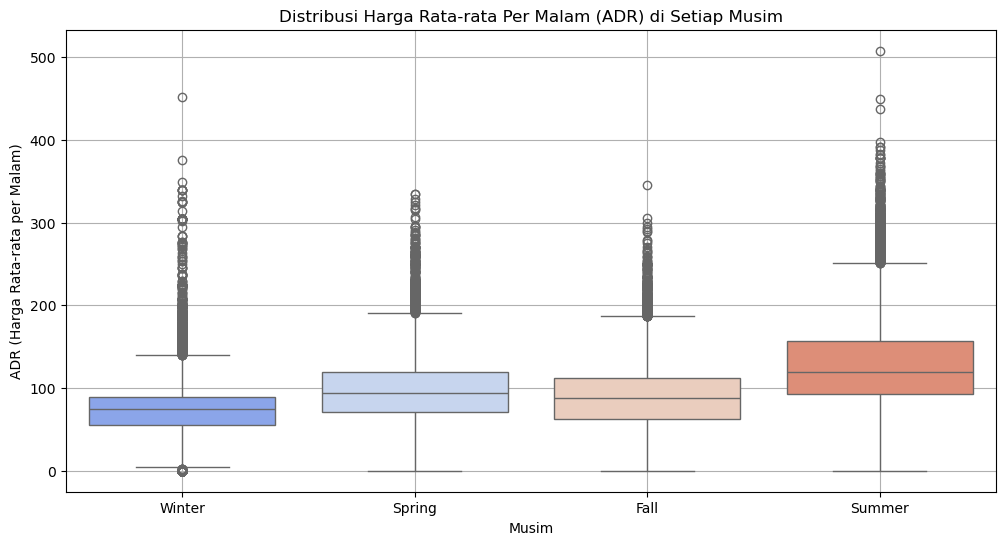

In [52]:
df["season"] = df["arrival_date_month"].map(season_map)

# Plot distribusi ADR per musim
plt.figure(figsize=(12,6))
sns.boxplot(x="season", y="adr", data=df, palette="coolwarm")
plt.xlabel("Musim")
plt.ylabel("ADR (Harga Rata-rata per Malam)")
plt.title("Distribusi Harga Rata-rata Per Malam (ADR) di Setiap Musim")
plt.grid(True)
plt.show()


Hasilnya:
- ADR pada winter(dingin) umumnya rendah, dengan sebagian besar reservasi di bawah 100.
- ADR sedikit lebih tinggi dari musim dingin, dengan kisaran yang lebih luas.
- Musim gugur(Fall) memiliki ADR mirip dengan musim semi serta harga optimal juga 
- Pada musim panas (Summer) banyak resevasi memiliki ADR diatas 100 dan beberapa diatas 200

Kesimpulan: musim yang berbeda memiliki pola harga optimal yang berbeda.
- Musim Panas memungkinkan harga tertinggi karena permintaan yang tinggi.
- Musim Dingin membutuhkan harga terendah untuk menarik tamu.
- Musim Semi dan Gugur memiliki pola harga yang serupa dan berada di antara musim panas dan dingin.

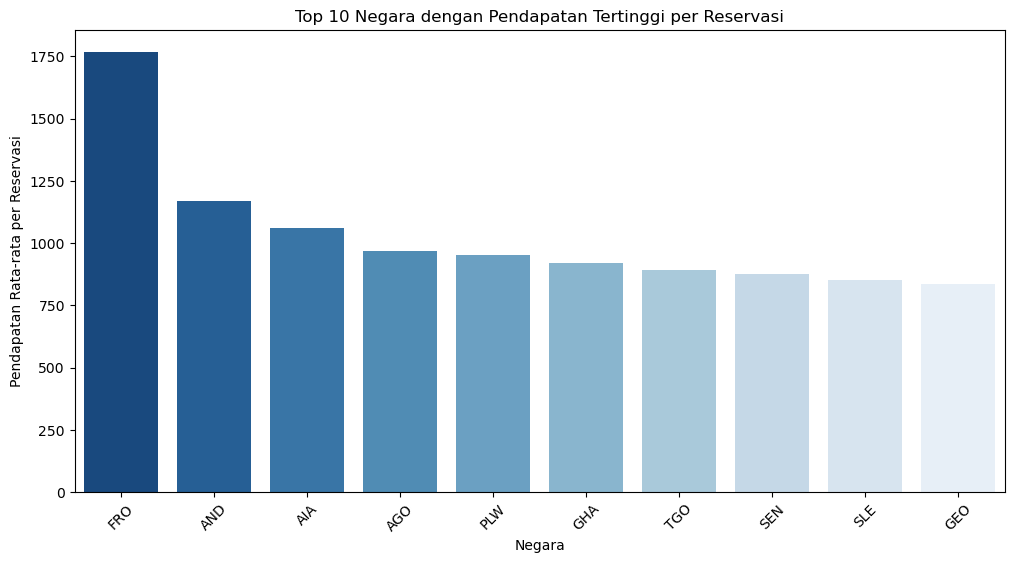

In [53]:
# Negara yang menghasilkan pendapatan per reservasi tertinggi

# Pendapatan per reservasi
df["total_revenue"] = df["adr"] * (df["stays_in_week_nights"] + df["stays_in_weekend_nights"])

# Rata-rata pendapatan per negara
revenue_per_country = (
    df.groupby("country")["total_revenue"].mean().sort_values(ascending=False).head(10)
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    x=revenue_per_country.index,
    y=revenue_per_country.values,
    palette="Blues_r",
    hue=revenue_per_country.index,  # Tambahkan hue
    legend=False,  # Hilangkan legenda jika tidak perlu
)



plt.xlabel("Negara")
plt.ylabel("Pendapatan Rata-rata per Reservasi")
plt.title("Top 10 Negara dengan Pendapatan Tertinggi per Reservasi")
plt.xticks(rotation=45)
plt.show()


Hasilnya:
- FRO (Kepulauan Faroe) memiliki pendapatan rata-rata per reservasi tertinggi
- Diikuti oleh negara AND, AIA, AGO dan seterusnya

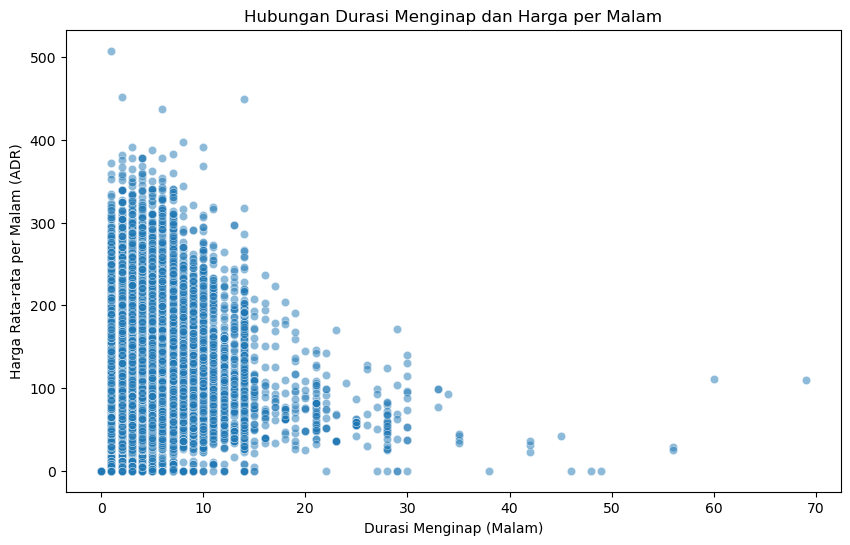

In [54]:
# Scatter plot antara durasi menginap dan harga rata-rata per malam (ADR)
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["stays_in_week_nights"] + df["stays_in_weekend_nights"], y=df["adr"], alpha=0.5)
plt.xlabel("Durasi Menginap (Malam)")
plt.ylabel("Harga Rata-rata per Malam (ADR)")
plt.title("Hubungan Durasi Menginap dan Harga per Malam")
plt.show()


Hasilnya:
- Grafik menunjukkan tren menurun secara umum antara durasi menginap dan ADR. Dengan kata lain, saat durasi menginap meningkat, harga rata-rata per malam cenderung menurun.
- Beberapa reservasi jangka pendek memiliki ADR yang sangat tinggi, sementara yang lain memiliki ADR yang lebih rendah.
- Saat durasi menginap bertambah (misalnya, lebih dari 10 malam), ADR cenderung lebih stabil dan umumnya lebih rendah. Ada lebih sedikit reservasi dengan ADR tinggi untuk durasi menginap yang lama.

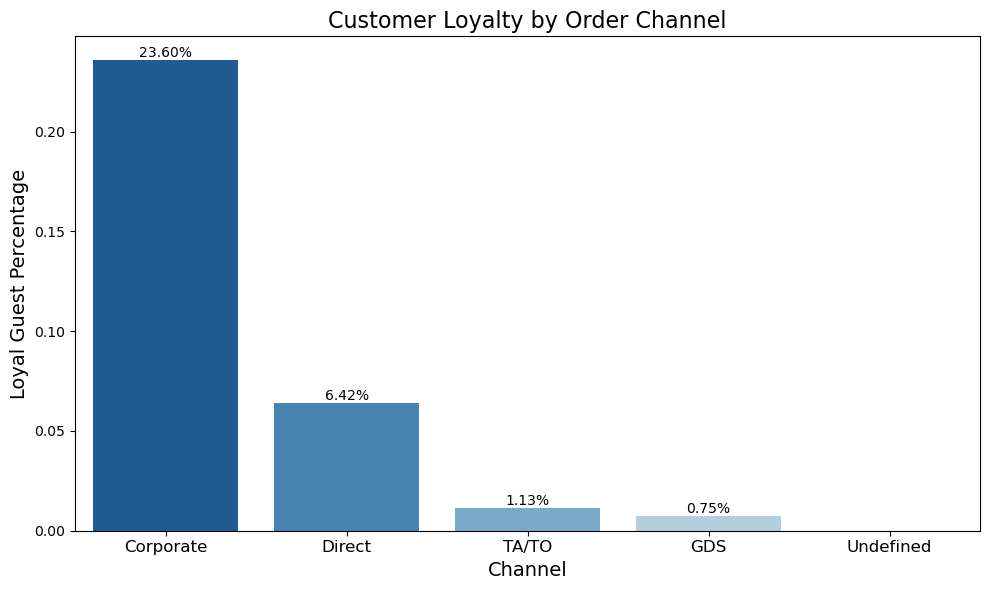

In [114]:
loyalty_by_channel = (
    df.groupby("distribution_channel")["is_repeated_guest"]
    .mean()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=loyalty_by_channel.index,
    y=loyalty_by_channel.values,
    palette="Blues_r",
    hue=loyalty_by_channel.index,  # Tambahkan hue
    legend=False,  # Tambahkan legend=False
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            "{:.2f}%".format(p.get_height() * 100),  # Format ke persentase dengan 2 desimal
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            fontsize=10,
            color="black",
            xytext=(0, 5),
            textcoords="offset points",
        )

plt.xlabel("Channel", fontsize=14)
plt.ylabel("Loyal Guest Percentage",fontsize=14)
plt.title("Customer Loyalty by Order Channel",fontsize=16)
plt.xticks( ha="center",fontsize=12)  # Tambahkan rotasi label x-axis
plt.tight_layout()  # Sesuaikan layout agar label tidak tumpang tindih
plt.show()

Hasilnya:
- Corporate termasuk chanel yang memiliki persentase tamu loyal tertinggi, yaitu 23.60%.
- Pelanggan yang memesan langsung (direct) memiliki tingkat loyalitas 6.42%.
- TA/TO (Travel Agent/Tour Operator)memiliki tingkat loyalitas 1.13%.
- GDS (Global Distribution System) memiliki tingkat loyalitas 0.75%.

Kesimpulannya:
- Pelanggan yang memesan melalui channel Corporate (perusahaan) jauh lebih loyal daripada pelanggan yang memesan melalui channel lain, termasuk individu yang memesan langsung (Direct).

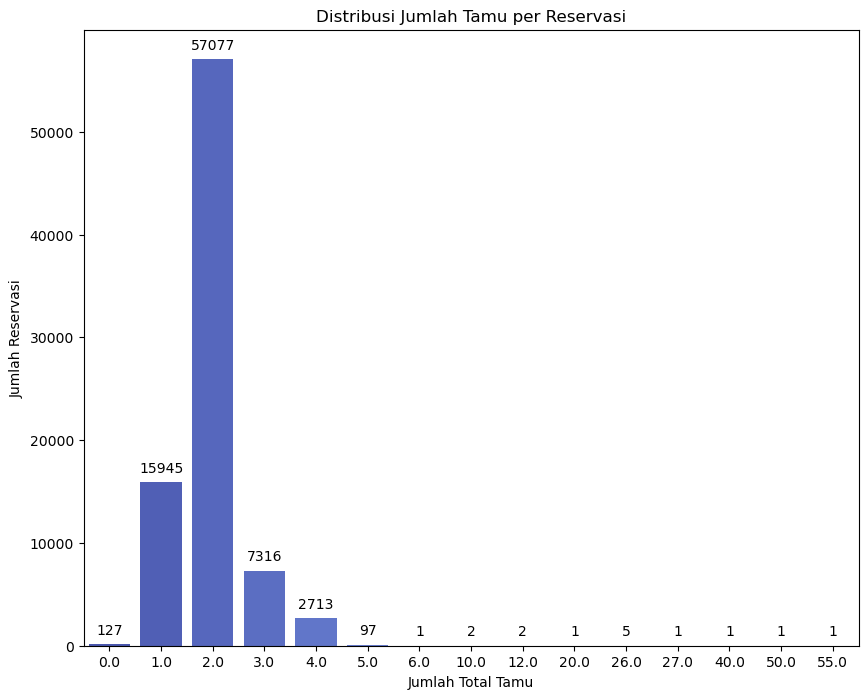

In [56]:
# Buat kategori jumlah tamu
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

# Plot distribusi jumlah tamu
plt.figure(figsize=(10, 8))
ax = sns.countplot(x=df["total_guests"], palette="coolwarm", hue=df["total_guests"], legend=False)  # Tambahkan hue dan legend=False
plt.xlabel("Jumlah Total Tamu")
plt.ylabel("Jumlah Reservasi")
plt.title("Distribusi Jumlah Tamu per Reservasi")

# Tambahkan label di atas bar
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.0f'),  # Format label sebagai integer
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),  # Offset label sedikit ke atas
        textcoords='offset points'
    )

plt.show()


Hasilnya:
- Jumlah reservasi tertinggi adalah untuk 2 tamu. Ini menunjukkan bahwa sebagian besar reservasi adalah untuk pasangan.
- Setelah puncak di 2 tamu, jumlah reservasi menurun drastis. Reservasi untuk 3 dan 4 tamu masih ada, tetapi jumlahnya jauh lebih rendah.
- Reservasi untuk jumlah tamu yang lebih besar (5 atau lebih) sangat jarang. Grafik menunjukkan batang yang sangat pendek atau tidak ada untuk nilai-nilai ini.

Kesimpulan:
- Mayoritas tamu adalah pasangan (2 tamu). Meskipun ada reservasi untuk keluarga kecil (3-4 tamu), jumlahnya jauh lebih sedikit dibandingkan dengan reservasi untuk pasangan. Reservasi untuk grup besar sangat jarang.
- sebagian besar reservasi adalah untuk 2 tamu, yang kemungkinan besar adalah pasangan. Reservasi untuk keluarga kecil ada tetapi jumlahnya lebih sedikit, dan reservasi untuk grup besar sangat jarang.

is_canceled
0    1.939180
1    2.012023
Name: total_guests, dtype: float64


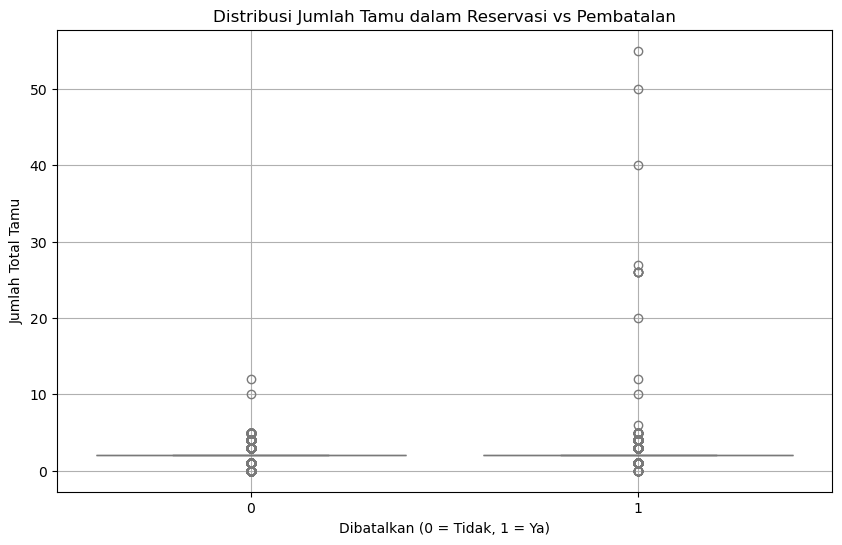

In [57]:
# Hitung jumlah total tamu
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

# Analisis rata-rata jumlah tamu untuk reservasi yang dibatalkan vs tidak
cancel_analysis = df.groupby("is_canceled")["total_guests"].mean()
print(cancel_analysis)

# Visualisasi distribusi jumlah tamu antara reservasi yang dibatalkan dan tidak
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="is_canceled",
    y="total_guests",
    data=df,
    palette="coolwarm",
    hue="is_canceled",  # Tambahkan hue
    legend=False,  # Tambahkan legend=False
)
plt.xlabel("Dibatalkan (0 = Tidak, 1 = Ya)")
plt.ylabel("Jumlah Total Tamu")
plt.title("Distribusi Jumlah Tamu dalam Reservasi vs Pembatalan")
plt.grid(True)
plt.show()


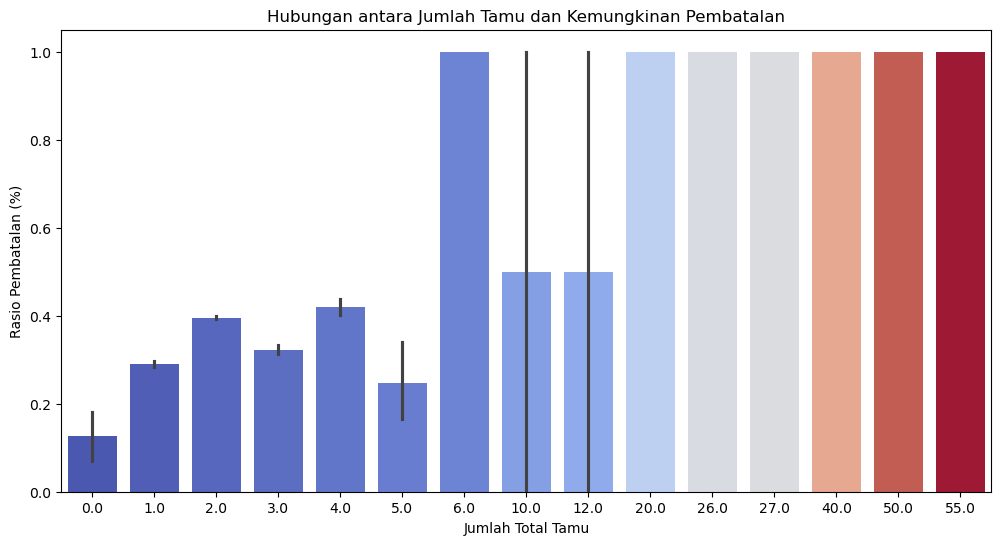

In [58]:
# Analisis tren pembatalan berdasarkan jumlah tamu
plt.figure(figsize=(12, 6))
sns.barplot(
    x=df["total_guests"],
    y=df["is_canceled"],
    estimator=lambda x: sum(x) / len(x),
    palette="coolwarm",
    hue=df["total_guests"],  # Tambahkan hue
    legend=False,  # Tambahkan legend=False
)
plt.xlabel("Jumlah Total Tamu")
plt.ylabel("Rasio Pembatalan (%)")
plt.title("Hubungan antara Jumlah Tamu dan Kemungkinan Pembatalan")
plt.show()


Hasilnya:
- Rasio pembatalan cenderung lebih tinggi untuk reservasi dengan 6 hingga 12 tamu.
- Reservasi dengan jumlah tamu yang sangat besar (di atas 20) juga memiliki rasio pembatalan yang tinggi.

Kesimpulan:
-  reservasi dengan jumlah tamu sedang dan besar lebih mungkin dibatalkan daripada reservasi dengan jumlah tamu kecil.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3592\967657939.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["is_repeated_guest"], y=df["stays_in_week_nights"] + df["stays_in_weekend_nights"], palette="coolwarm")


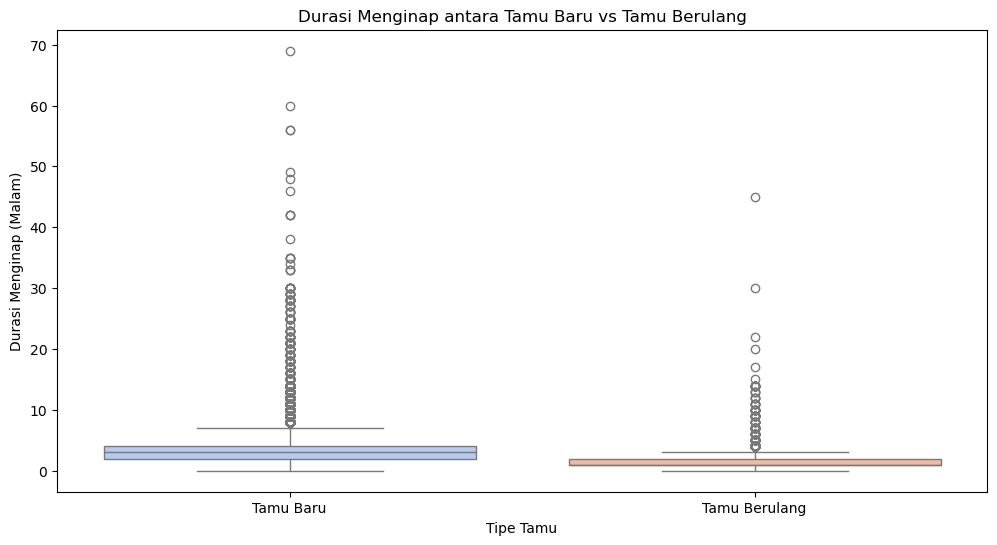

In [59]:
# Bandingkan repeated guest dengan total jumlah menginap dan booking changes
plt.figure(figsize=(12,6))
sns.boxplot(x=df["is_repeated_guest"], y=df["stays_in_week_nights"] + df["stays_in_weekend_nights"], palette="coolwarm")
plt.xticks([0, 1], ["Tamu Baru", "Tamu Berulang"])
plt.xlabel("Tipe Tamu")
plt.ylabel("Durasi Menginap (Malam)")
plt.title("Durasi Menginap antara Tamu Baru vs Tamu Berulang")
plt.show()


Hasilnya:
- Tamu berulang cenderung memiliki median durasi menginap yang lebih pendek dibandingkan tamu baru.
- Tamu berulang memiliki IQR yang lebih kecil, yang berarti durasi menginap mereka lebih konsisten dan kurang bervariasi dibandingkan tamu baru.
- Tamu baru memiliki lebih banyak pencilan dengan durasi menginap yang sangat lama dibandingkan tamu berulang.

Kesimpulannya:
- Tamu berulang cenderung menginap dengan durasi yang lebih pendek dan lebih konsisten dibandingkan tamu baru. Meskipun ada beberapa tamu berulang yang menginap cukup lama, sebagian besar tamu berulang memilih untuk menginap dalam jangka waktu yang lebih singkat.

In [60]:
# Buat kolom apakah kamar yang dipesan = kamar yang diberikan
df["room_match"] = df["reserved_room_type"] == df["assigned_room_type"]

# Hitung persentase kesesuaian tipe kamar
match_rate = df["room_match"].mean() * 100
print(f"Tingkat kesesuaian kamar yang dipesan dengan yang diberikan: {match_rate:.2f}%")


Tingkat kesesuaian kamar yang dipesan dengan yang diberikan: 87.49%


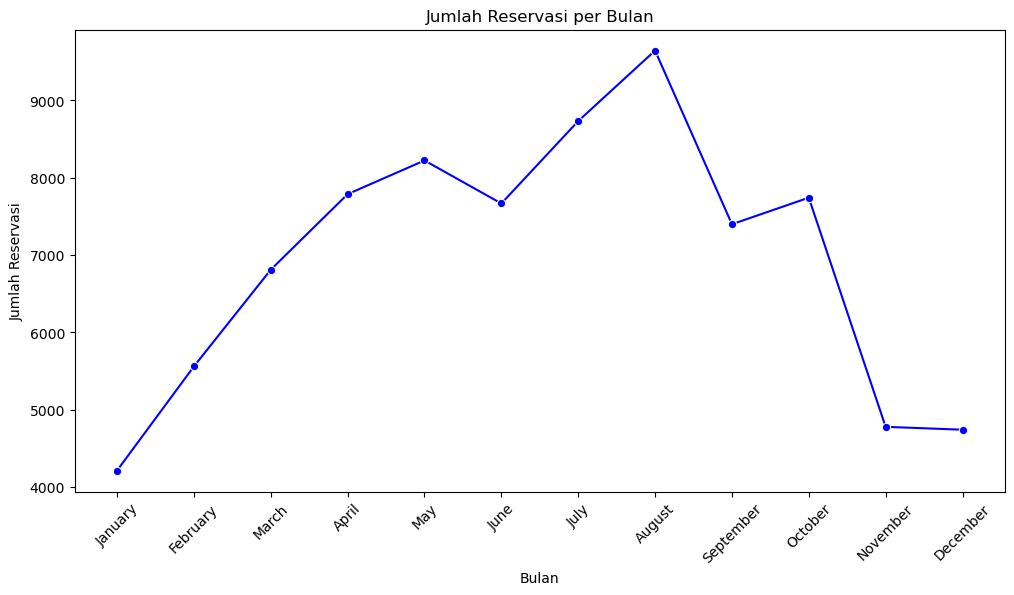

In [61]:
# Hitung jumlah reservasi per bulan
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"], categories=[
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"], ordered=True)

reservations_by_month = df["arrival_date_month"].value_counts().sort_index()

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(x=reservations_by_month.index, y=reservations_by_month.values, marker="o", color="b")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Reservasi")
plt.title("Jumlah Reservasi per Bulan")
plt.xticks(rotation=45)
plt.show()


Hasilnya:
- Berdasarkan grafik "Jumlah Reservasi per Bulan", waktu puncak reservasi hotel adalah di bulan Agustus.
- Diikiti bulan July, May, April, June
- Januari menjadi low season yang merupakan reservasi terendah di bulan tersebut

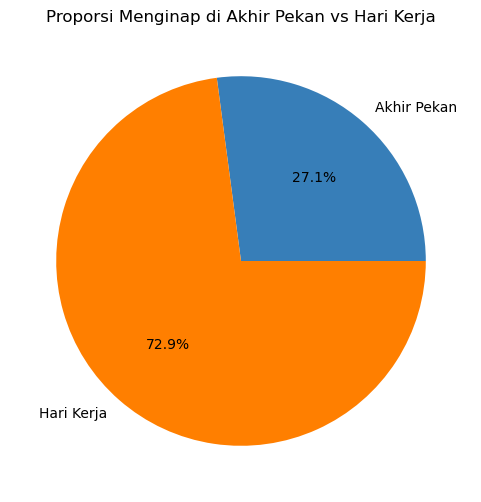

In [62]:
# Hitung total malam di weekday dan weekend
weekend_nights = df["stays_in_weekend_nights"].sum()
weekday_nights = df["stays_in_week_nights"].sum()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie([weekend_nights, weekday_nights], labels=["Akhir Pekan", "Hari Kerja"], autopct="%1.1f%%", colors=['#377eb8', '#ff7f00'])
plt.title("Proporsi Menginap di Akhir Pekan vs Hari Kerja")
plt.show()


Hasilnya:
- Customer lebih suka menginap pada hari kerja

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3592\523946538.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loyalty_by_requests.index, y=loyalty_by_requests.values, palette="coolwarm")


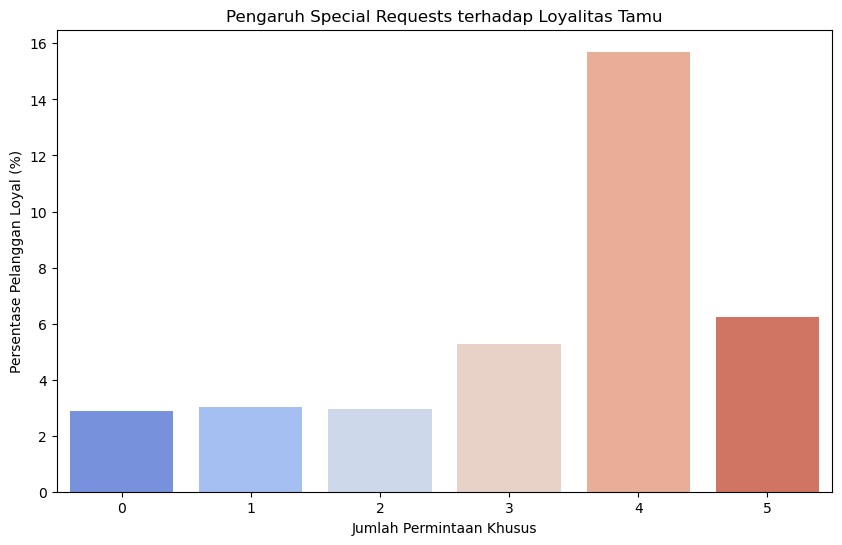

In [63]:
# Hitung rata-rata loyalitas berdasarkan jumlah special requests
loyalty_by_requests = df.groupby("total_of_special_requests")["is_repeated_guest"].mean() * 100

# Visualisasi
plt.figure(figsize=(10,6))
sns.barplot(x=loyalty_by_requests.index, y=loyalty_by_requests.values, palette="coolwarm")
plt.xlabel("Jumlah Permintaan Khusus")
plt.ylabel("Persentase Pelanggan Loyal (%)")
plt.title("Pengaruh Special Requests terhadap Loyalitas Tamu")
plt.show()

Hasilnya:
-  Tamu yang mengajukan permintaan khusus dan permintaannya dipenuhi merasa lebih dihargai dan diperhatikan, yang pada akhirnya meningkatkan loyalitas mereka.

Kesimpulan:
- Pemenuhan permintaan khusus memiliki pengaruh positif terhadap loyalitas tamu. Semakin banyak permintaan khusus yang dipenuhi, semakin tinggi kemungkinan tamu untuk menjadi loyal.

Bisnis:
- Personalisasi Layanan: Menawarkan personalisasi layanan berdasarkan permintaan khusus dapat meningkatkan pengalaman tamu dan membangun hubungan yang lebih kuat.
- Manajemen Harapan: Penting untuk mengelola harapan tamu terkait permintaan khusus dan memastikan bahwa mereka memahami batasan dan ketersediaan layanan.

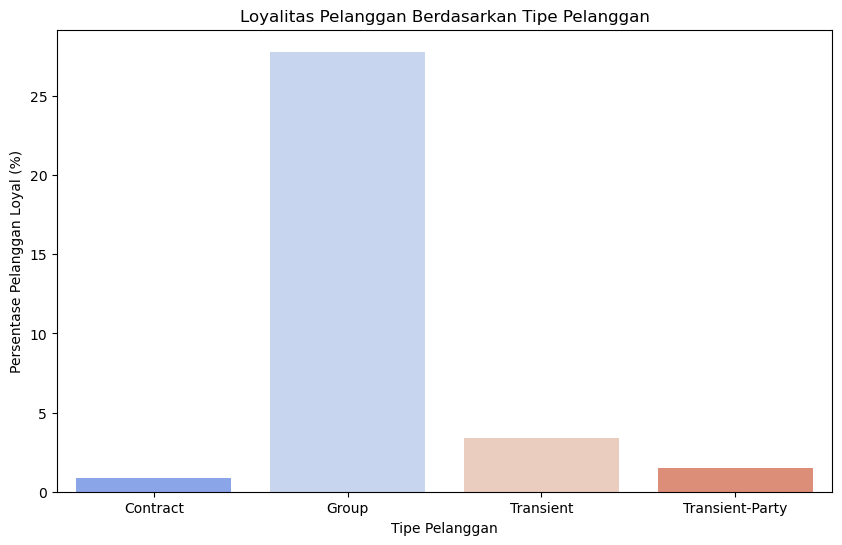

In [67]:
loyalty_by_customer_type = df.groupby("customer_type")["is_repeated_guest"].mean() * 100

# Visualisasi
plt.figure(figsize=(10,6))
sns.barplot(x=loyalty_by_customer_type.index, y=loyalty_by_customer_type.values, palette="coolwarm", hue=loyalty_by_customer_type.index, legend=False) # perubahan pada bagian ini
plt.xlabel("Tipe Pelanggan")
plt.ylabel("Persentase Pelanggan Loyal (%)")
plt.title("Loyalitas Pelanggan Berdasarkan Tipe Pelanggan")
plt.show()

Hasilnya:
- Tipe pelanggan Group memiliki loyalitas dibandingkan tipe pelanggan yang lainnya

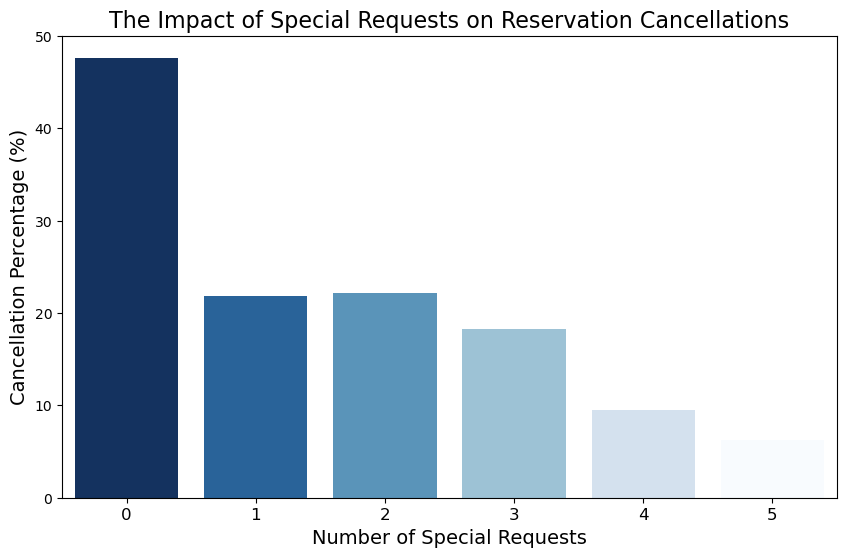

In [121]:
cancellation_by_requests = df.groupby("total_of_special_requests")["is_canceled"].mean() * 100

# Visualisasi dengan perbaikan
plt.figure(figsize=(10,6))
sns.barplot(x=cancellation_by_requests.index, y=cancellation_by_requests.values, palette="Blues_r", hue=cancellation_by_requests.index, legend=False) # Perbaikan di sini
plt.xlabel("Number of Special Requests", fontsize=14)
plt.ylabel("Cancellation Percentage (%)",fontsize=14)
plt.title("The Impact of Special Requests on Reservation Cancellations",fontsize=16)
plt.xticks(fontsize=12) 
plt.show()

Hasilnya:
- Permintaan khusus mungkin menunjukkan bahwa tamu lebih terlibat dan tertarik dengan penginapan mereka, sehingga mereka lebih kecil kemungkinannya untuk membatalkan.
- Hotel dapat mempertimbangkan untuk mendorong permintaan khusus, karena ini dapat membantu mengurangi tingkat pembatalan.

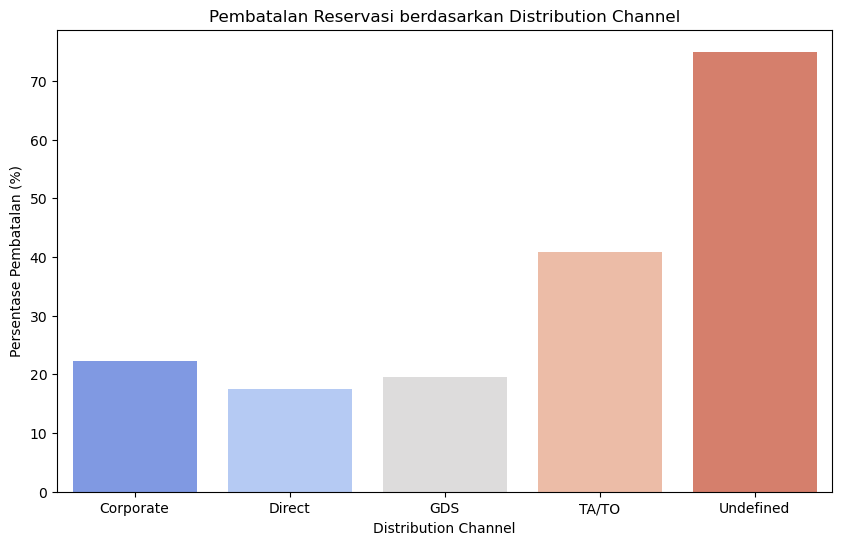

In [74]:
cancellation_by_channel = df.groupby("distribution_channel")["is_canceled"].mean() * 100

# Visualisasi yang diperbaiki
plt.figure(figsize=(10,6))
sns.barplot(x=cancellation_by_channel.index, y=cancellation_by_channel.values, palette="coolwarm", hue=cancellation_by_channel.index, legend=False) # Perbaikan di sini
plt.xlabel("Distribution Channel")
plt.ylabel("Persentase Pembatalan (%)")
plt.title("Pembatalan Reservasi berdasarkan Distribution Channel")
plt.show()

Hasilnya:
- TA/TO memiliki tingkat pembatalan yang tinggi
- Direct memiliki tingkat pembatalan paling rendah dibandingkan yang lainnya

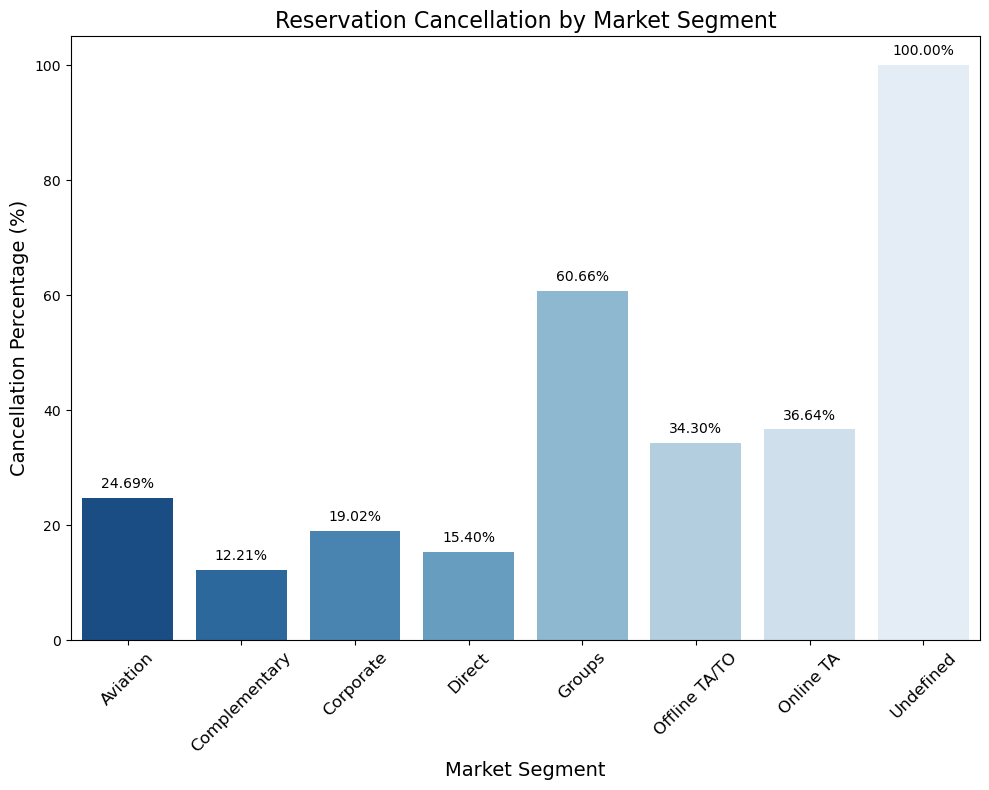

In [109]:
cancellation_by_segment = df.groupby("market_segment")["is_canceled"].mean() * 100

# Visualisasi yang diperbaiki
plt.figure(figsize=(10,8))
ax = sns.barplot(x=cancellation_by_segment.index, y=cancellation_by_segment.values, palette="Blues_r", hue=cancellation_by_segment.index, legend=False)

# Menambahkan label di atas setiap bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',  # Format label dengan 2 desimal dan tanda persen
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),  # Sedikit geser label ke atas
        textcoords='offset points'
    )

plt.xlabel("Market Segment", fontsize=14)
plt.ylabel("Cancellation Percentage (%)",fontsize=14)
plt.title("Reservation Cancellation by Market Segment", fontsize=16)
plt.xticks(rotation=45,fontsize=12)
plt.tight_layout() #menghindari label yang terpotong
plt.show()

Hasilnya:
- Market segment group memiliki tingkat pembatalan tinggi

Rata-rata ADR untuk reservasi yang tidak dibatalkan: 100.00
Rata-rata ADR untuk reservasi yang dibatalkan: 104.67
Selisih ADR: 4.67


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22336\2287695828.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_canceled', y='adr', data=df, palette='coolwarm')


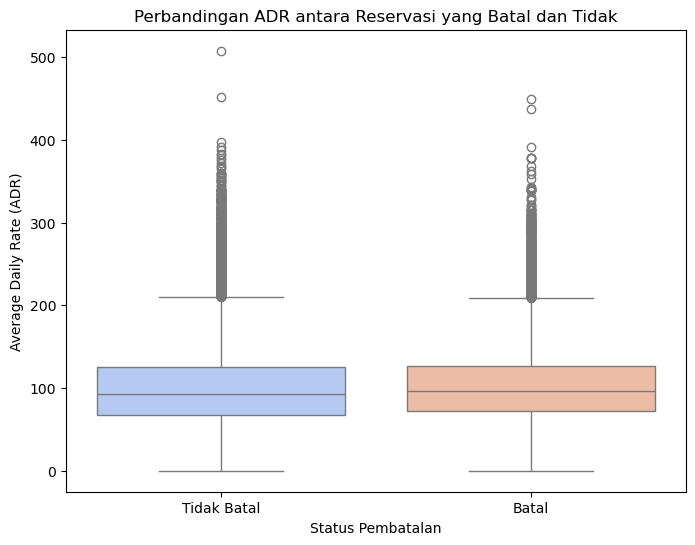

In [124]:
# Hitung rata-rata ADR untuk reservasi yang tidak dibatalkan (is_canceled == 0)
adr_tidak_batal = df[df['is_canceled'] == 0]['adr'].mean()

# Hitung rata-rata ADR untuk reservasi yang dibatalkan (is_canceled == 1)
adr_batal = df[df['is_canceled'] == 1]['adr'].mean()

# Hitung selisih ADR
selisih_adr = adr_batal - adr_tidak_batal

# Tampilkan hasil
print(f"Rata-rata ADR untuk reservasi yang tidak dibatalkan: {adr_tidak_batal:.2f}")
print(f"Rata-rata ADR untuk reservasi yang dibatalkan: {adr_batal:.2f}")
print(f"Selisih ADR: {selisih_adr:.2f}")

# Visualisasi (opsional)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='is_canceled', y='adr', data=df, palette='coolwarm')
plt.xticks([0, 1], ['Tidak Batal', 'Batal'])
plt.xlabel('Status Pembatalan')
plt.ylabel('Average Daily Rate (ADR)')
plt.title('Perbandingan ADR antara Reservasi yang Batal dan Tidak')
plt.show()


hotel
African Pride Melrose Arch, Autograph Collection Johannesburg, South Africa    37.399679
Albuquerque Airport Courtyard Albuquerque, NM                                  36.377358
Anaheim Marriott Anaheim, CA                                                   36.926606
Baltimore BWI Airport Courtyard Linthicum, MD                                  38.131123
Baton Rouge Acadian Centre/LSU Area Courtyard Baton Rouge, LA                  36.302395
                                                                                 ...    
W Barcelona Barcelona, Spain                                                   36.096458
W London – Leicester Square London, United Kingdom                             36.288505
W New York – Times Square New York, NY                                         36.573705
W New York – Union Square New York, NY                                         36.400000
Waves, Barbados Barbados                                                       38.519637
Name: is_cancel

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22336\1949436425.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancel_rate.index, y=cancel_rate.values, palette="coolwarm")


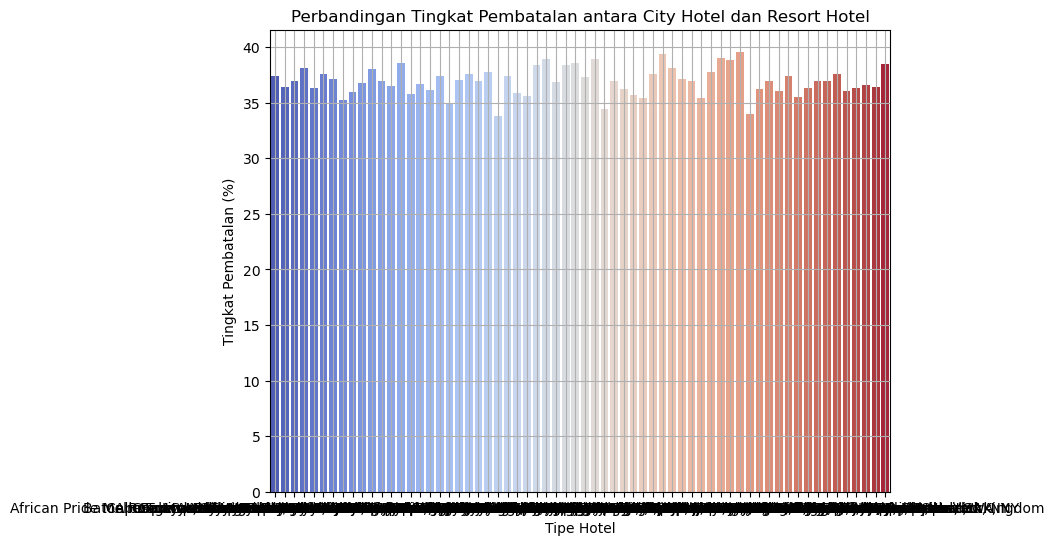

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22336\1949436425.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="hotel", y="total_nights", data=df, palette="coolwarm")


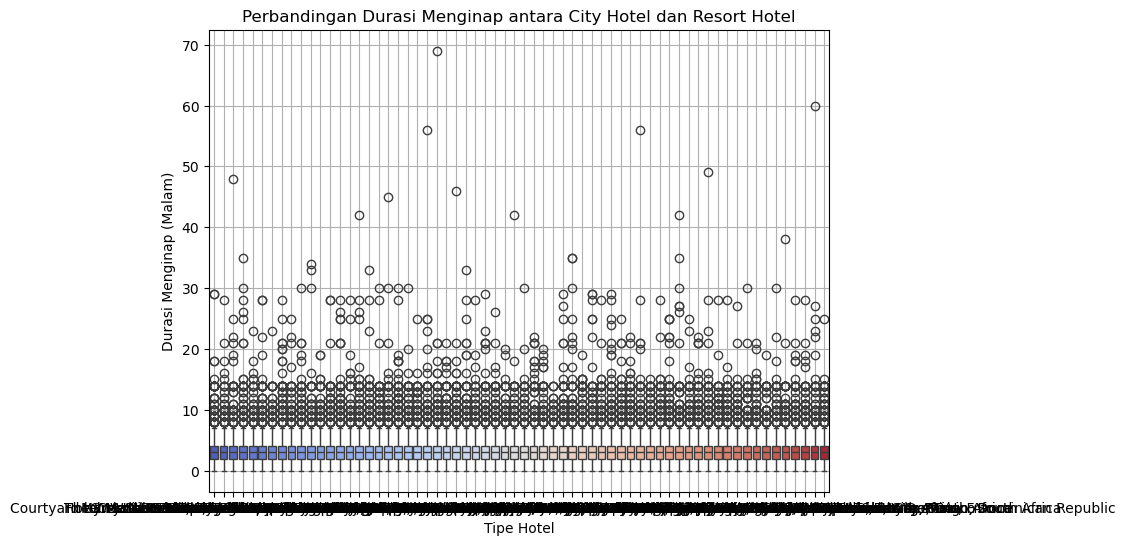

In [119]:
# Bandingkan tingkat pembatalan antara City Hotel dan Resort Hotel
cancel_rate = df.groupby("hotel")["is_canceled"].mean() * 100
print(cancel_rate)

# Bandingkan durasi menginap (weekday + weekend) antara kedua tipe hotel
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
stay_duration = df.groupby("hotel")["total_nights"].mean()
print(stay_duration)

# Visualisasi tingkat pembatalan
plt.figure(figsize=(8,6))
sns.barplot(x=cancel_rate.index, y=cancel_rate.values, palette="coolwarm")
plt.xlabel("Tipe Hotel")
plt.ylabel("Tingkat Pembatalan (%)")
plt.title("Perbandingan Tingkat Pembatalan antara City Hotel dan Resort Hotel")
plt.grid(True)
plt.show()

# Visualisasi durasi menginap
plt.figure(figsize=(8,6))
sns.boxplot(x="hotel", y="total_nights", data=df, palette="coolwarm")
plt.xlabel("Tipe Hotel")
plt.ylabel("Durasi Menginap (Malam)")
plt.title("Perbandingan Durasi Menginap antara City Hotel dan Resort Hotel")
plt.grid(True)
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3592\2382696378.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adr_trend = df.groupby("arrival_date_month")["adr"].mean().reindex(month_order)


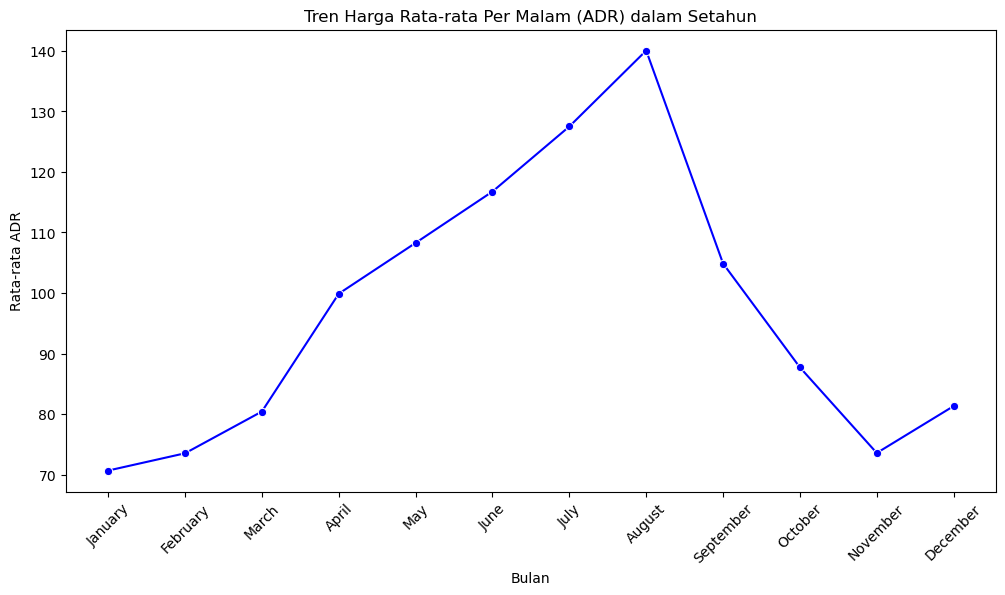

In [81]:
# Konversi nama bulan menjadi urutan angka agar lebih mudah diproses
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Hitung rata-rata ADR per bulan
adr_trend = df.groupby("arrival_date_month")["adr"].mean().reindex(month_order)

# Plot hasilnya
plt.figure(figsize=(12,6))
sns.lineplot(x=adr_trend.index, y=adr_trend.values, marker="o", color="b")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata ADR")
plt.title("Tren Harga Rata-rata Per Malam (ADR) dalam Setahun")
plt.xticks(rotation=45)
plt.show()

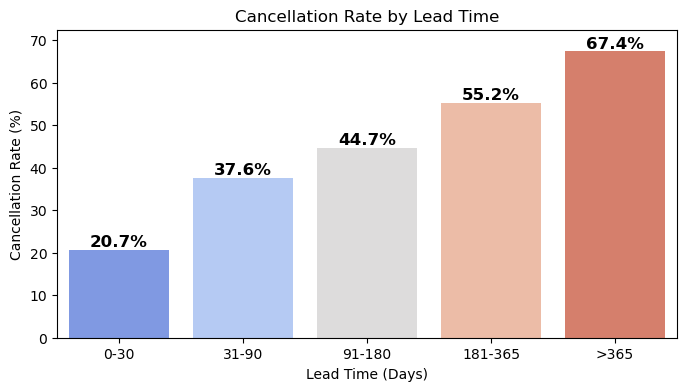

In [80]:
df["lead_time_group"] = pd.cut(df["lead_time"], bins=[0, 30, 90, 180, 365, 800],
                                labels=["0-30", "31-90", "91-180", "181-365", ">365"])

cancel_lead = df.groupby("lead_time_group", observed=True)["is_canceled"].mean() * 100 # Perbaikan di sini

# Visualisasi
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=cancel_lead.index, y=cancel_lead.values, palette="coolwarm", hue=cancel_lead.index, legend=False) # Perbaikan di sini

# Menambahkan label di atas setiap bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel("Cancellation Rate (%)")
plt.xlabel("Lead Time (Days)")
plt.title("Cancellation Rate by Lead Time")
plt.ylim(0, max(cancel_lead.values) + 5)  # Menyesuaikan batas atas sumbu Y agar label terlihat
plt.show()

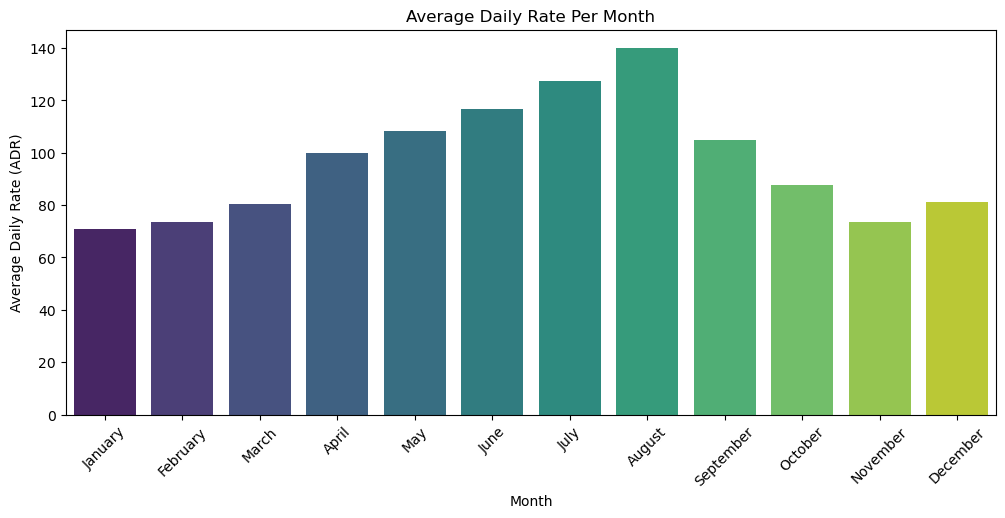

In [79]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']

df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"], categories=month_order, ordered=True)

# Rata-rata ADR per bulan
adr_per_month = df.groupby("arrival_date_month", observed=True)["adr"].mean()  # Perbaikan di sini

plt.figure(figsize=(12, 5))
sns.barplot(x=adr_per_month.index, y=adr_per_month.values, palette="viridis", hue=adr_per_month.index, legend=False) # Perbaikan di sini
plt.ylabel("Average Daily Rate (ADR)")
plt.xlabel("Month")
plt.title("Average Daily Rate Per Month")
plt.xticks(rotation=45)
plt.show()

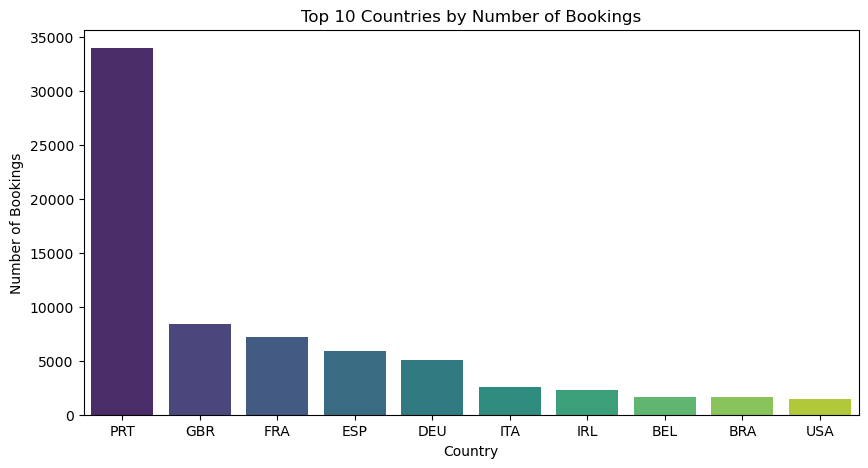

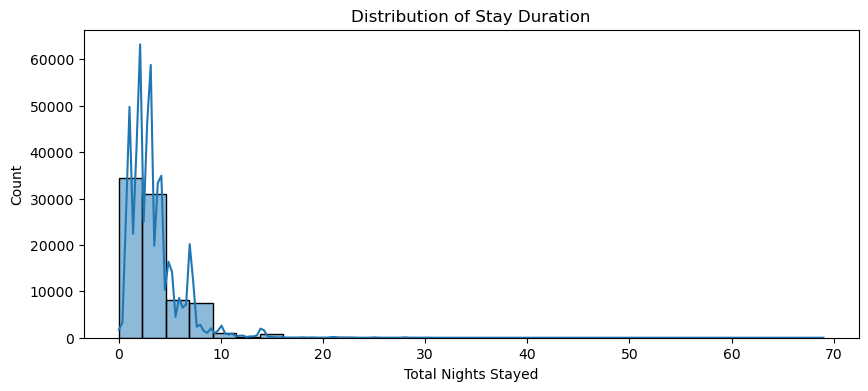

In [76]:
top_countries = df["country"].value_counts().nlargest(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.index, y=top_countries.values, palette="viridis", hue=top_countries.index, legend=False) # Perbaikan di sini
plt.ylabel("Number of Bookings")
plt.xlabel("Country")
plt.title("Top 10 Countries by Number of Bookings")
plt.show()

# Distribusi lama menginap
df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]

plt.figure(figsize=(10, 4))
sns.histplot(df["total_nights"], bins=30, kde=True)
plt.xlabel("Total Nights Stayed")
plt.title("Distribution of Stay Duration")
plt.show()

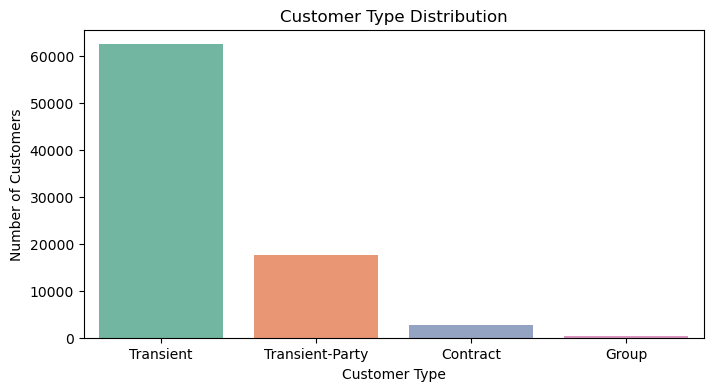

In [78]:
customer_type_counts = df["customer_type"].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=customer_type_counts.index, y=customer_type_counts.values, palette="Set2", hue=customer_type_counts.index, legend=False) # Perbaikan di sini
plt.ylabel("Number of Customers")
plt.xlabel("Customer Type")
plt.title("Customer Type Distribution")
plt.show()

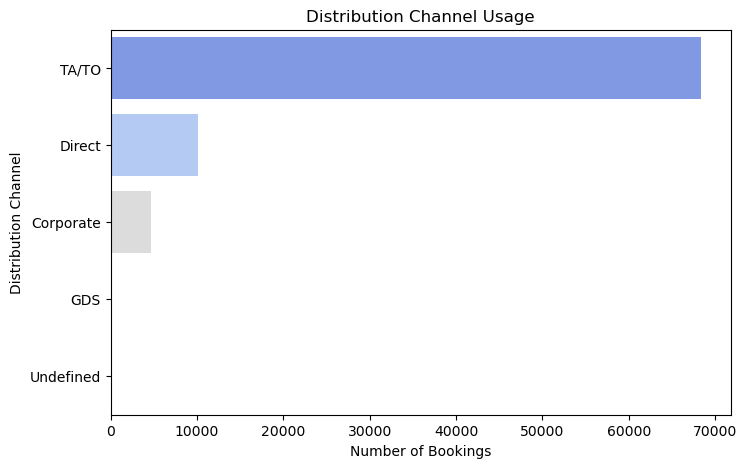

In [77]:
channel_counts = df["distribution_channel"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(y=channel_counts.index, x=channel_counts.values, palette="coolwarm", hue=channel_counts.index, legend=False) # Perbaikan di sini
plt.xlabel("Number of Bookings")
plt.ylabel("Distribution Channel")
plt.title("Distribution Channel Usage")
plt.show()

# Preprocessing
1. Drop Duplicated data
2. Missing Value Handling
3. Outlier Analysis

In [48]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83290 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            

In [49]:
# Change type data
X['reservation_status_date']=pd.to_datetime(X['reservation_status_date'])

### Check Duplicate

In [50]:
# check duplicate
X[X.duplicated(keep=False)]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID


There are not duplicated

### Missing Value

#### Check Each Column

In [51]:
X.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              3
babies                                0
meal                                  0
country                             346
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             11404
company                           78559


In [52]:
# Percentage missing value
print('missing value of agent:', 11404*100/83293)
print('missing value of company:', 78559*100/83293)

missing value of agent: 13.691426650498842
missing value of company: 94.31644916139412


In [53]:
# Handling missing value
# X=X[X['children'].notna()]
# X.loc[:, 'country'] = X['country'].fillna(['country'].mode()[0])
# X.loc[:, 'agent']=X['agent'].fillna(X['agent'].median())
# X=X.drop(['company'],axis='columns')

#Delete column company
X.drop(['company'], axis='columns', inplace=True)
#Handling missing value pada column country dan agent
X=X[X['children'].notna()]
X['agent'].fillna(X['agent'].median(),inplace=True)
X['country'].fillna(X['country'].mode()[0],inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33552\628261319.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['agent'].fillna(X['agent'].median(),inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33552\628261319.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['agent'].fillna(X['agent'].median(),inplace=True)
C:\Users\Leno

In [54]:
#check missing value
X.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

#### Check NaN

In [55]:
#check NaN
X.isnull().sum().sum()

0

In [56]:
#check Nan
X.isnull().any().any()

False

In [57]:
count_nan= X.isnull().sum()
print ('Count of NaN: ' + str(count_nan))

Count of NaN: hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_p

In [58]:
for column in X.columns:
    print(f"============= {column} =================")
    display(X[column].value_counts())
    print()

============= hotel =================


hotel
Renaissance New York Times Square Hotel New York, NY                           1373
Sacramento Airport Natomas Courtyard Sacramento, CA                            1372
Las Vegas Marriott Las Vegas, NV                                               1371
Crystal Cove, Barbados Barbados                                                1360
Protea Hotel by Marriott Midrand Midrand, South Africa                         1352
                                                                               ... 
W New York – Union Square New York, NY                                         1250
The House, Barbados Barbados                                                   1249
Sheraton Grand Rio Hotel & Resort Rio de Janeiro, Brazil                       1249
African Pride Melrose Arch, Autograph Collection Johannesburg, South Africa    1246
Residence Inn Rio de Janeiro Barra da Tijuca Barra da Tijuca, Brazil           1246
Name: count, Length: 64, dtype: int64


============= is_canceled =================


is_canceled
0    52516
1    30774
Name: count, dtype: int64


============= lead_time =================


...

reservation_status
Check-Out    52516
Canceled     29920
No-Show        854
Name: count, dtype: int64


============= reservation_status_date =================


reservation_status_date
2017-10-21    1024
2018-11-25     560
2017-07-06     558
2017-01-01     535
2018-01-18     437
              ... 
2017-01-18       1
2017-02-12       1
2017-03-30       1
2017-03-23       1
2017-03-29       1
Name: count, Length: 914, dtype: int64


============= bookingID =================


bookingID
1        1
55517    1
55535    1
55534    1
55533    1
        ..
27764    1
27763    1
27762    1
27761    1
83293    1
Name: count, Length: 83290, dtype: int64

#### Handling Miss Input

In [59]:
# Reservation Status
X['reservation_status']=X['reservation_status'].replace('No-Show','Canceled')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33552\3707048569.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['reservation_status']=X['reservation_status'].replace('No-Show','Canceled')


In [60]:
X['adults']=X['adults'].replace(0, 1)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33552\2252963236.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['adults']=X['adults'].replace(0, 1)


In [61]:
for column in X.columns:
    print(f"============= {column} =================")
    display(X[column].value_counts())
    print()

============= hotel =================


hotel
Renaissance New York Times Square Hotel New York, NY                           1373
Sacramento Airport Natomas Courtyard Sacramento, CA                            1372
Las Vegas Marriott Las Vegas, NV                                               1371
Crystal Cove, Barbados Barbados                                                1360
Protea Hotel by Marriott Midrand Midrand, South Africa                         1352
                                                                               ... 
W New York – Union Square New York, NY                                         1250
The House, Barbados Barbados                                                   1249
Sheraton Grand Rio Hotel & Resort Rio de Janeiro, Brazil                       1249
African Pride Melrose Arch, Autograph Collection Johannesburg, South Africa    1246
Residence Inn Rio de Janeiro Barra da Tijuca Barra da Tijuca, Brazil           1246
Name: count, Length: 64, dtype: int64


============= is_canceled =================


is_canceled
0    52516
1    30774
Name: count, dtype: int64


============= lead_time =================


...

reservation_status
Check-Out    52516
Canceled     30774
Name: count, dtype: int64


============= reservation_status_date =================


reservation_status_date
2017-10-21    1024
2018-11-25     560
2017-07-06     558
2017-01-01     535
2018-01-18     437
              ... 
2017-01-18       1
2017-02-12       1
2017-03-30       1
2017-03-23       1
2017-03-29       1
Name: count, Length: 914, dtype: int64


============= bookingID =================


bookingID
1        1
55517    1
55535    1
55534    1
55533    1
        ..
27764    1
27763    1
27762    1
27761    1
83293    1
Name: count, Length: 83290, dtype: int64

### Check Outlier

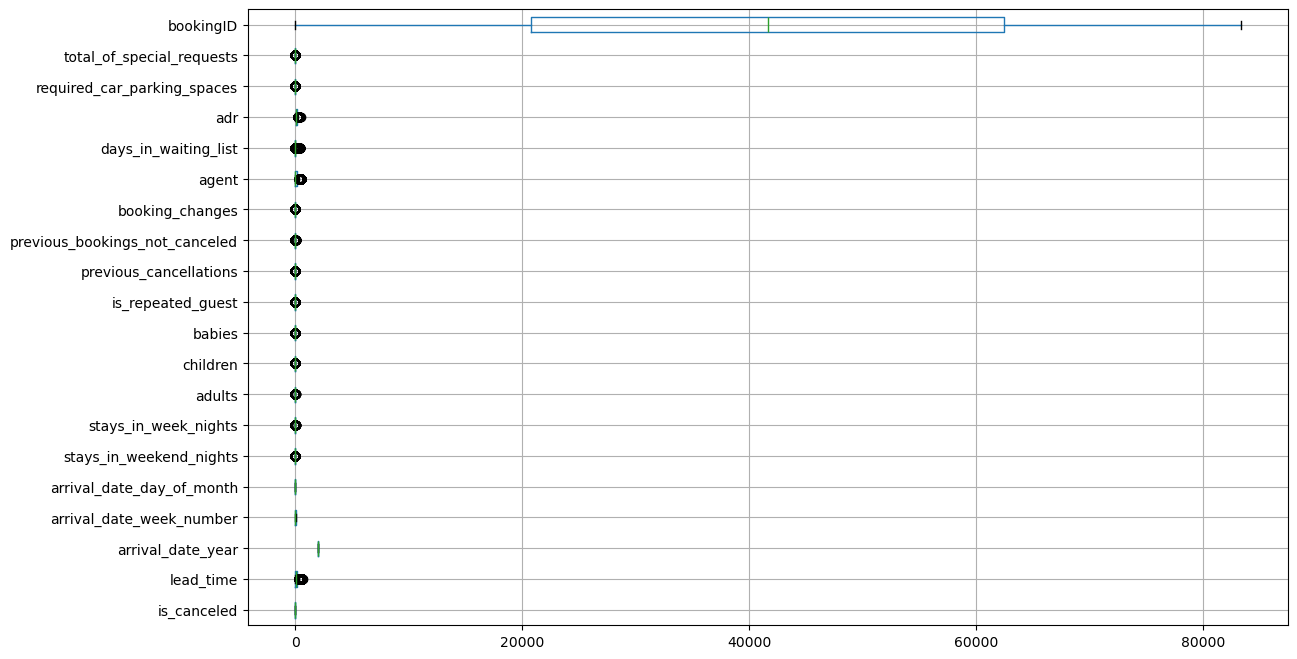

In [62]:
plt.figure(figsize=(16,8))

#create boxplot
X.boxplot(vert=False)
plt.subplots_adjust(left=0.25)
plt.show()

In [63]:
# Check Outlier
outlier_count={}
numericals=X.select_dtypes(include=['float64','int64']).columns
for column in numericals:
    Q1=X[column].quantile(0.25)
    Q3=X[column].quantile(0.75)
    IQR= Q3-Q1
    lower_bond=Q1-(IQR*1.5)
    upper_bond=Q3+(IQR*1.5)
    outlier=X[(X[column]<lower_bond)|
    (X[column]>upper_bond)]
    outlier_count[column]=outlier.shape[0]
for column, count in outlier_count.items():
    print(f'Outlier in {column}: {count}')

Outlier in is_canceled: 0
Outlier in lead_time: 2112
Outlier in arrival_date_year: 0
Outlier in arrival_date_week_number: 0
Outlier in arrival_date_day_of_month: 0
Outlier in stays_in_weekend_nights: 196
Outlier in stays_in_week_nights: 2355
Outlier in adults: 20919
Outlier in children: 5961
Outlier in babies: 643
Outlier in is_repeated_guest: 2519
Outlier in previous_cancellations: 4397
Outlier in previous_bookings_not_canceled: 2532
Outlier in booking_changes: 12703
Outlier in agent: 869
Outlier in days_in_waiting_list: 2594
Outlier in adr: 2672
Outlier in required_car_parking_spaces: 5109
Outlier in total_of_special_requests: 2017
Outlier in bookingID: 0


Setelah di cek dan dilakukan handling outlier pada kolom berikut menjadi 1 nilai uniq jadi diputuskan untuk tidak di handling outlier:
1. adults
2. children
3. babies
4. previous_cancellations
5. previous_bookings_not_canceled
6. booking_changes
7. days_in_waiting_list
8. required_car_parking_spaces


In [64]:
X.shape

(83290, 32)

In [65]:
#Outlier lead_time
Q1=X['lead_time'].quantile(0.25)
Q3=X['lead_time'].quantile(0.75)
IQR= Q3-Q1
lower_bond=Q1-(IQR*1.5)
upper_bond=Q3+(IQR*1.5)
outlier1=X[(X['lead_time']<lower_bond)|
    (X['lead_time']>upper_bond)]
print('Outlier lead_time')
print(outlier1['lead_time'].sort_values(ascending=False))

Outlier lead_time
65083    737
80931    629
453      629
45314    629
3214     629
        ... 
23247    374
40158    374
13651    374
4067     374
9392     374
Name: lead_time, Length: 2112, dtype: int64


In [66]:
#Handling lead time outlier
X['lead_time']=X['lead_time'].apply(
    lambda x: lower_bond if x < lower_bond else upper_bond if x > upper_bond else x
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33552\3781447388.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['lead_time']=X['lead_time'].apply(


In [67]:
#Outlier stays_in_weekend_nights
Q1=X['stays_in_weekend_nights'].quantile(0.25)
Q3=X['stays_in_weekend_nights'].quantile(0.75)
IQR= Q3-Q1
lower_bond=Q1-(IQR*1.5)
upper_bond=Q3+(IQR*1.5)
outlier1=X[(X['stays_in_weekend_nights']<lower_bond)|
    (X['stays_in_weekend_nights']>upper_bond)]
print('Outlier stays_in_weekend_nights')
print(outlier1['stays_in_weekend_nights'].sort_values(ascending=False))

Outlier stays_in_weekend_nights
3441     19
48416    18
55783    16
62885    16
71792    14
         ..
30952     6
31641     6
33149     6
34629     6
39506     6
Name: stays_in_weekend_nights, Length: 196, dtype: int64


In [68]:
# Handlig stays_in_weekend_nights outlier
X['stays_in_weekend_nights']=X['stays_in_weekend_nights'].apply(
    lambda x: lower_bond if x < lower_bond else upper_bond if x > upper_bond else x
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33552\291866944.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['stays_in_weekend_nights']=X['stays_in_weekend_nights'].apply(


In [69]:
# Outlier stays_in_week_nights
Q1=X['stays_in_week_nights'].quantile(0.25)
Q3=X['stays_in_week_nights'].quantile(0.75)
IQR= Q3-Q1
lower_bond=Q1-(IQR*1.5)
upper_bond=Q3+(IQR*1.5)
outlier1=X[(X['stays_in_week_nights']<lower_bond)|
    (X['stays_in_week_nights']>upper_bond)]
print('Outlier stays_in_week_nights')
print(outlier1['stays_in_week_nights'].sort_values(ascending=False))

Outlier stays_in_week_nights
3441     50
48416    42
55783    40
62885    40
54172    35
         ..
59187     7
12054     7
59305     7
12032     7
10869     7
Name: stays_in_week_nights, Length: 2355, dtype: int64


In [70]:
# Handlig stays_in_week_nights outlier
X=X[(X['stays_in_week_nights']>=lower_bond) &
    (X['stays_in_week_nights']<=upper_bond)
    ]

In [71]:
X.shape

(80935, 32)

In [72]:
#Outlier adr
Q1=X['adr'].quantile(0.25)
Q3=X['adr'].quantile(0.75)
IQR= Q3-Q1
lower_bond=Q1-(IQR*1.5)
upper_bond=Q3+(IQR*1.5)
outlier1=X[(X['adr']<lower_bond)|
    (X['adr']>upper_bond)]
print('Outlier adr')
print(outlier1['adr'].sort_values(ascending=False))

Outlier adr
35400    508.00
24167    451.50
30258    437.00
28461    397.38
6511     392.00
          ...  
12796    210.51
6419     210.50
9496     210.40
19529    210.33
53058    210.03
Name: adr, Length: 2578, dtype: float64


In [73]:
#Handling adr outlier
X['adr']=X['adr'].apply(
    lambda x: lower_bond if x < lower_bond else upper_bond if x > upper_bond else x
)

In [74]:
X.shape

(80935, 32)

In [75]:
#Outlier total_of_special_requests
Q1=X['total_of_special_requests'].quantile(0.25)
Q3=X['total_of_special_requests'].quantile(0.75)
IQR= Q3-Q1
lower_bond=Q1-(IQR*1.5)
upper_bond=Q3+(IQR*1.5)
outlier1=X[(X['total_of_special_requests']<lower_bond)|
    (X['total_of_special_requests']>upper_bond)]
print('Outlier total_of_special_requests')
print(outlier1['total_of_special_requests'].sort_values(ascending=False))

Outlier total_of_special_requests
49961    5
54985    5
23215    5
4145     5
17532    5
        ..
28026    3
27968    3
27932    3
27863    3
83278    3
Name: total_of_special_requests, Length: 1937, dtype: int64


In [76]:
#handling total_of_special_requests outlier
X=X[(X['total_of_special_requests']>=lower_bond)&
    (X['total_of_special_requests']<=upper_bond)
]

In [77]:
X.shape

(78998, 32)

In [78]:
for column in X.columns:
    print(f"============= {column} =================")
    display(X[column].value_counts())
    print()

============= hotel =================


hotel
Renaissance New York Times Square Hotel New York, NY                           1298
Sacramento Airport Natomas Courtyard Sacramento, CA                            1297
Las Vegas Marriott Las Vegas, NV                                               1295
Crystal Cove, Barbados Barbados                                                1288
Sheraton Lima Hotel & Convention Center Lima, Peru                             1288
                                                                               ... 
Sheraton Grand Rio Hotel & Resort Rio de Janeiro, Brazil                       1186
St. Louis Downtown West Courtyard St. Louis, MO                                1185
W New York – Times Square New York, NY                                         1185
The House, Barbados Barbados                                                   1181
African Pride Melrose Arch, Autograph Collection Johannesburg, South Africa    1179
Name: count, Length: 64, dtype: int64


============= is_canceled =================


is_canceled
0    49377
1    29621
Name: count, dtype: int64


============= lead_time =================


...

reservation_status
Check-Out    49377
Canceled     29621
Name: count, dtype: int64


============= reservation_status_date =================


reservation_status_date
2017-10-21    1018
2018-11-25     558
2017-07-06     556
2017-01-01     535
2018-01-18     429
              ... 
2017-03-23       1
2017-04-30       1
2017-02-26       1
2017-01-18       1
2017-03-29       1
Name: count, Length: 907, dtype: int64


============= bookingID =================


bookingID
1        1
55519    1
55526    1
55525    1
55524    1
        ..
27794    1
27793    1
27792    1
27791    1
83293    1
Name: count, Length: 78998, dtype: int64

## Encoding Train Test Data

In [79]:
X.drop(columns=['reservation_status_date'], inplace=True)
X.drop(columns=['reservation_status'], inplace=True)
X.drop(columns=['bookingID'], inplace=True)

In [80]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78998 entries, 0 to 83292
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           78998 non-null  object 
 1   is_canceled                     78998 non-null  int64  
 2   lead_time                       78998 non-null  float64
 3   arrival_date_year               78998 non-null  int64  
 4   arrival_date_month              78998 non-null  object 
 5   arrival_date_week_number        78998 non-null  int64  
 6   arrival_date_day_of_month       78998 non-null  int64  
 7   stays_in_weekend_nights         78998 non-null  float64
 8   stays_in_week_nights            78998 non-null  int64  
 9   adults                          78998 non-null  int64  
 10  children                        78998 non-null  float64
 11  babies                          78998 non-null  int64  
 12  meal                            78998

In [81]:
# import pandas as pd

# # Aktifkan opsi agar Pandas mengikuti aturan baru (mencegah warning)
# pd.set_option('future.no_silent_downcasting', True)

# # Contoh membaca dataset (pastikan X sudah ada)
# # X = pd.read_csv("data.csv")

# # Pastikan X bukan None sebelum transformasi
# if X is not None:
#     # Mapping kategori ke numerik
#     mapping_dictionary = {
#         'deposit_type': {'No Deposit': 0, 'Non Refund': 1, 'Refundable': 2},
#         'customer_type': {'Transient': 0, 'Contract': 1, 'Transient-Party': 2, 'Group': 3}
#     }

#     X = X.replace(mapping_dictionary)

#     # Mapping bulan ke angka
#     replace_dictionary = {
#         'arrival_date_month': {
#             'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5,
#             'June': 6, 'July': 7, 'August': 8, 'September': 9, 'October': 10,
#             'November': 11, 'December': 12
#         }
#     }

#     X = X.replace(replace_dictionary)  # Hilangkan inplace=True

#     # One-Hot Encoding hanya untuk kolom yang ada dalam dataset
#     categorical_cols = ['meal', 'market_segment', 'distribution_channel',
#                         'reserved_room_type', 'assigned_room_type', 'country']

#     existing_cols = [col for col in categorical_cols if col in X.columns]  # Cek dulu sebelum encode
#     X = pd.get_dummies(X, columns=existing_cols, drop_first=True)

#     # Cek hasil transformasi
#     print(X.head())

# else:
#     print("Error: Dataset X belum didefinisikan atau nilainya None.")


In [82]:
import pandas as pd

# pd.set_option('future.no_silent_downcasting', True)


# Mapping kategori ke numerik
mapping_dictionary = {
    'deposit_type': {'No Deposit': 0, 'Non Refund': 1, 'Refundable': 2},
    'customer_type': {'Transient': 0, 'Contract': 1, 'Transient-Party': 2, 'Group': 3}
    }

X.replace(mapping_dictionary, inplace=True)


replace_dictionary = {
    'arrival_date_month': {
        'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5,
        'June': 6, 'July': 7, 'August': 8, 'September': 9, 'October': 10,
        'November': 11, 'December': 12
    }
}
X.replace(replace_dictionary, inplace=True)

# One-Hot Encoding
columns_to_encode = ['hotel','meal', 'market_segment', 'distribution_channel',
                     'reserved_room_type', 'assigned_room_type', 'country']

X = pd.get_dummies(X, columns=columns_to_encode, drop_first=True, dtype=int)
X.head()

    # X = X.astype(int)

    # Konversi semua ke tipe numerik (int)
    # X = X.apply(pd.to_numeric, errors='coerce')  # Ganti errors='ignore' dengan 'coerce'


    # return X



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33552\2668454187.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.replace(mapping_dictionary, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33552\2668454187.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.replace(replace_dictionary, inplace=True)


,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,country_UKR,country_UMI,country_URY,country_USA,country_UZB,country_VEN,country_VNM,country_ZAF,country_ZMB,country_ZWE
0,0,8.0,2019,1,2,10,0.0,4,2,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1,373.0,2018,12,51,15,0.0,2,2,0.0,...,0,0,0,0,0,0,0,0,0,0
2,1,175.0,2019,5,20,19,1.0,2,2,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0,0.0,2018,10,43,17,1.0,0,1,0.0,...,0,0,0,0,0,0,0,0,0,0
4,1,33.0,2017,9,39,26,2.0,3,2,0.0,...,0,0,0,0,0,0,0,0,0,0


# Feature Enginering

In [83]:
from sklearn.model_selection import train_test_split

train, test =train_test_split(X, test_size=0.2, random_state=42)

In [84]:
# Kolom target
target_column = 'is_canceled'

## Scalling

In [85]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
# Kolom yang akan di Standarize
columns_to_scale=['lead_time','arrival_date_week_number','arrival_date_day_of_month',
        'stays_in_weekend_nights','stays_in_week_nights','adults','children','babies',
        'previous_cancellations','previous_bookings_not_canceled','booking_changes',
        'days_in_waiting_list','adr','required_car_parking_spaces','total_of_special_requests']

# Inisialisasi StandarScaler
scaler=StandardScaler()

# Fit dan transformasi data train
train[columns_to_scale]=scaler.fit_transform(train[columns_to_scale])

# Hanya transformasi data test
test[columns_to_scale]=scaler.transform(test[columns_to_scale])

In [86]:
train.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,country_UKR,country_UMI,country_URY,country_USA,country_UZB,country_VEN,country_VNM,country_ZAF,country_ZMB,country_ZWE
82722,0,-0.455300,2017,8,0.578046,1.168357,-0.974474,-0.208059,0.229936,-0.254909,...,0,0,0,0,0,0,0,0,0,0
82783,0,0.332895,2019,3,-1.032720,1.740002,1.318205,0.496712,0.229936,-0.254909,...,0,0,0,0,0,0,0,0,0,0
28391,0,-0.790284,2019,7,0.065530,-0.546579,-0.974474,0.496712,0.229936,-0.254909,...,0,0,0,0,0,0,0,0,0,0
78556,0,1.396959,2019,5,-0.520203,0.025066,1.318205,1.906254,-1.351462,-0.254909,...,0,0,0,0,0,0,0,0,0,0
33896,0,0.027469,2018,12,1.895946,1.054028,1.318205,-0.912830,-1.351462,4.869048,...,0,0,0,0,0,0,0,0,0,0


In [87]:
test.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,country_UKR,country_UMI,country_URY,country_USA,country_UZB,country_VEN,country_VNM,country_ZAF,country_ZMB,country_ZWE
2972,0,-0.711464,2018,7,0.285180,1.397015,-0.974474,-0.912830,0.229936,-0.254909,...,0,0,0,0,0,0,0,0,0,0
17275,1,0.224518,2018,10,1.236996,1.054028,-0.974474,0.496712,0.229936,-0.254909,...,0,0,0,0,0,0,0,0,0,0
20870,0,-0.849398,2019,2,-1.545236,-1.118224,0.171866,-0.208059,-1.351462,-0.254909,...,0,0,0,0,0,0,0,0,0,0
10303,0,-0.928218,2017,10,1.236996,1.511344,-0.974474,-0.912830,-1.351462,-0.254909,...,0,0,0,0,0,0,0,0,0,0
399,0,2.234417,2018,9,0.944129,1.625673,-0.974474,-0.208059,0.229936,-0.254909,...,0,0,0,0,0,0,0,0,0,0


## Split into Xtrain, ytrain, Xtest, ytest

In [88]:
Xtrain=train.drop(columns=[target_column])
ytrain=train[target_column]

Xtest=test.drop(columns=[target_column])
ytest=test[target_column]

print('There are {} samples in the training set and {} samples in the test set.'.format(
    Xtrain.shape[0], Xtest.shape[0]))

There are 63198 samples in the training set and 15800 samples in the test set.


# Modelling

In [89]:
#Membangun model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb
models={
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    # 'Support Vector Machine': SVC(probability=True,class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'XGBoost': xgb.XGBClassifier(eval_metric='logloss'),
    # 'LightGBM': lgb.LGBMClassifier(force_col_wise=True)

}




In [90]:
from sklearn.metrics import recall_score, precision_score, f1_score

# Fungsi untuk menghitung dan menampilkan metrik
def evaluate_models(Xtrain, ytrain, Xtest, ytest, use_smote=False):
    results = {}

# Melatih dan mengevaluasi setiap model
    for model_name, model in models.items():
        print(f"Model: {model_name}")

        # Melatih model dengan data pelatihan
        model.fit(Xtrain, ytrain)
        
        # Prediksi untuk data pelatihan dan pengujian
        ytrain_pred = model.predict(Xtrain)
        ytest_pred = model.predict(Xtest)
        
        # Menghitung metrik untuk train dataset
        # train_accuracy = accuracy_score(ytrain, ytrain_pred)
        train_recall = recall_score(ytrain, ytrain_pred, average='weighted')
        train_precision = precision_score(ytrain, ytrain_pred, average='weighted')
        train_f1 = f1_score(ytrain, ytrain_pred, average='weighted')
        # train_roc_auc = roc_auc_score(ytrain, model.predict_proba(Xtrain), multi_class='ovr', average='weighted')
        
        # Menghitung metrik untuk test dataset
        # test_accuracy = accuracy_score(ytest, ytest_pred)
        test_recall = recall_score(ytest, ytest_pred, average='weighted')
        test_precision = precision_score(ytest, ytest_pred, average='weighted')
        test_f1 = f1_score(ytest, ytest_pred, average='weighted')
        # test_roc_auc = roc_auc_score(ytest, model.predict_proba(Xtest), multi_class='ovr', average='weighted')

        # Menampilkan hasil metrik untuk train dan test
        print(f"Train Metrics:")
        # print(f"  Accuracy: {train_accuracy:.4f}")
        print(f"  Recall: {train_recall:.4f}")
        print(f"  Precision: {train_precision:.4f}")
        print(f"  F1-Score: {train_f1:.4f}")
        # print(f"  ROC-AUC: {train_roc_auc:.4f}")
        
        print(f"Test Metrics:")
        # print(f"  Accuracy: {test_accuracy:.4f}")
        print(f"  Recall: {test_recall:.4f}")
        print(f"  Precision: {test_precision:.4f}")
        print(f"  F1-Score: {test_f1:.4f}")
        # print(f"  ROC-AUC: {test_roc_auc:.4f}")
        print()
        
        # Menyimpan hasil F1 score untuk dibandingkan antar model
        results[model_name] = {
            'train_recall': train_recall,
            'train_precision': train_precision,
            'train_f1': train_f1,
            'test_recall': test_recall,
            'test_precision': test_precision,
            'test_f1': test_f1
        }
    
    return results

In [91]:
results = evaluate_models(Xtrain, ytrain, Xtest, ytest)

Model: Logistic Regression


c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train Metrics:
  Recall: 0.8132
  Precision: 0.8129
  F1-Score: 0.8085
Test Metrics:
  Recall: 0.8084
  Precision: 0.8077
  F1-Score: 0.8032

Model: Random Forest
Train Metrics:
  Recall: 0.9996
  Precision: 0.9996
  F1-Score: 0.9996
Test Metrics:
  Recall: 0.8820
  Precision: 0.8827
  F1-Score: 0.8802

Model: Decision Tree
Train Metrics:
  Recall: 0.9996
  Precision: 0.9996
  F1-Score: 0.9996
Test Metrics:
  Recall: 0.8430
  Precision: 0.8431
  F1-Score: 0.8431

Model: Gradient Boosting
Train Metrics:
  Recall: 0.8549
  Precision: 0.8546
  F1-Score: 0.8527
Test Metrics:
  Recall: 0.8476
  Precision: 0.8471
  F1-Score: 0.8451

Model: K-Nearest Neighbors
Train Metrics:
  Recall: 0.8888
  Precision: 0.8882
  F1-Score: 0.8882
Test Metrics:
  Recall: 0.8320
  Precision: 0.8307
  F1-Score: 0.8310

Model: XGBoost
Train Metrics:
  Recall: 0.8956
  Precision: 0.8951
  F1-Score: 0.8951
Test Metrics:
  Recall: 0.8715
  Precision: 0.8707
  F1-Score: 0.8707



## Model Terbaiknya

In [93]:
# Menentukan best model berdasarkan test F1-score
def get_best_model(results):
    best_model = max(results, key=lambda model: results[model]['test_f1'])
    best_f1_score = results[best_model]['test_f1']
    
    print(f"Best Model: {best_model}")
    print(f"Best Test F1-Score: {best_f1_score:.4f}")
    
    return best_model, best_f1_score

# Menentukan best model tanpa SMOTE
best_model_without_smote, best_f1_without_smote = get_best_model(results)


Best Model: Random Forest
Best Test F1-Score: 0.8802


## Tuning Hyperparameter

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

# Tentukan parameter grid untuk RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 200],  # Jumlah estimators (pohon)
    'max_depth': [3, 5, 7],  # Kedalaman pohon
    'min_samples_split': [2, 5, 10],  # Minimum samples untuk split
    'min_samples_leaf': [1, 2, 4],  # Minimum samples untuk leaf
    'bootstrap': [True, False]  # Aktifkan atau nonaktifkan bootstrap sampling
}

# Inisialisasi model Random Forest
rf = RandomForestClassifier(random_state=42)

# Inisialisasi GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='f1_weighted', verbose=2)

# Melakukan pencarian grid pada data latih (Xtrain, ytrain)
grid_search.fit(Xtrain, ytrain)

# Menampilkan parameter terbaik dan skor terbaik dari training (cross-validation)
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best F1 Score (Train - CV): {grid_search.best_score_:.4f}")

# Ambil model terbaik dari hasil tuning
best_model = grid_search.best_estimator_

# Evaluasi model pada data training
ytrain_pred = best_model.predict(Xtrain)
train_f1 = f1_score(ytrain, ytrain_pred, average='weighted')
print(f"Train F1 Score: {train_f1:.4f}")

# Evaluasi model pada data uji (Xtest)
ytest_pred = best_model.predict(Xtest)
test_f1 = f1_score(ytest, ytest_pred, average='weighted')
print(f"Test F1 Score: {test_f1:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Hyperparameters: {'bootstrap': True, 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best F1 Score (Train - CV): 0.7519
Train F1 Score: 0.7444
Test F1 Score: 0.7402


In [95]:
# Menggunakan model terbaik untuk prediksi
y_pred = results[best_model_without_smote]['model'].predict(X_test)

# Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Canceled", "Canceled"], yticklabels=["Not Canceled", "Canceled"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - {best_model_without_smote}")
plt.show()

# Menampilkan Classification Report
print(f"Classification Report for {best_model_without_smote}:\n")
print(classification_report(y_test, y_pred))


KeyError: 'model'

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


# # Inisialisasi model
# models = {
#     'Logistic Regression': LogisticRegression(),
#     'K-Nearest Neighbours': KNeighborsClassifier(),
#     'Naive Bayes': GaussianNB(),
#     'Support Vector Machine': SVC(probability=True),
#     'Decision Tree': DecisionTreeClassifier(),
#     'Random Forest': RandomForestClassifier(),
#     'Gradient Boosting': GradientBoostingClassifier()
# }

# # Dictionary untuk menyimpan hasil evaluasi
# evaluation_results = {}

# # Looping untuk setiap model
# for model_name, model in models.items():
#     # Melatih model pada data train
#     model.fit(Xtrain, ytrain)

#     # Prediksi pada data train dan test
#     ytrain_pred = model.predict(Xtrain)
#     ytest_pred = model.predict(Xtest)

#     # Probabilitas prediksi untuk ROC-AUC (gunakan predict_proba jika ada, jika tidak gunakan predict)
#     if hasattr(model, "predict_proba"):
#         ytrain_prob = model.predict_proba(Xtrain)[:, 1]
#         ytest_prob = model.predict_proba(Xtest)[:, 1]
#     else:
#         ytrain_prob = ytrain_pred
#         ytest_prob = ytest_pred

#     # Evaluasi pada train
#     train_accuracy = accuracy_score(ytrain, ytrain_pred)
#     train_recall = recall_score(ytrain, ytrain_pred)
#     train_precision = precision_score(ytrain, ytrain_pred)
#     train_f1 = f1_score(ytrain, ytrain_pred)
#     train_roc_auc = roc_auc_score(ytrain, ytrain_prob)

#     # Evaluasi pada test
#     test_accuracy = accuracy_score(ytest, ytest_pred)
#     test_recall = recall_score(ytest, ytest_pred)
#     test_precision = precision_score(ytest, ytest_pred)
#     test_f1 = f1_score(ytest, ytest_pred)
#     test_roc_auc = roc_auc_score(ytest, ytest_prob)

#     # Menyimpan hasil evaluasi
#     evaluation_results[model_name] = {
#         'Train': {
#             'Accuracy': train_accuracy,
#             'Recall': train_recall,
#             'Precision': train_precision,
#             'F1-Score': train_f1,
#             'ROC-AUC': train_roc_auc
#         },
#         'Test': {
#             'Accuracy': test_accuracy,
#             'Recall': test_recall,
#             'Precision': test_precision,
#             'F1-Score': test_f1,
#             'ROC-AUC': test_roc_auc
#         }
#     }

# # Menampilkan hasil evaluasi
# for model_name, results in evaluation_results.items():
#     print(f"\nModel: {model_name}")
#     print("Train Metrics:")
#     for metric, value in results['Train'].items():
#         print(f"  {metric}: {value:.4f}")
#     print("Test Metrics:")
#     for metric, value in results['Test'].items():
#         print(f"  {metric}: {value:.4f}")


c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
